# XGBoost 回归与可解释性分析

## 1. 数据准备、建模与评估


### 1.0 全局配置
配置程序主要参数，包括数据来源、模型来源
必须允许该程序块

In [17]:
# ==================== 全局配置（优先修改这里） ====================
from pathlib import Path
import re
import pandas as pd

# 项目程序根目录：自动获取
PROJECT_ROOT = Path.cwd()

# 数据文件路径 与 目标列、需排除列
DATA_PATH = PROJECT_ROOT / "Example" / "ALL_data_analysis" / "ALL_exp._results.csv"
TARGET_COLUMN = "titer(mg/L)"
ANALYSIS_ROUND = ["control","R1","R2","R3",] #"R4",
DROP_COLUMNS = ["remarks","output per unit medium cost (mg/CNY)" ]


# 设定并创建输出目录：同名文件会被新结果覆盖，
OUTPUT_ROOT = PROJECT_ROOT / "Example" / "ALL_data_analysis" / "SHAP_outputs"
MODELING_OUTPUT_DIR = OUTPUT_ROOT / "01_modeling"
PDP_OUTPUT_DIR = OUTPUT_ROOT / "02_pdp"
SHAP_MAIN_OUTPUT_DIR = OUTPUT_ROOT / "03_shap_main"
SHAP_INTERACTION_OUTPUT_DIR = OUTPUT_ROOT / "04_shap_interaction"
LIME_OUTPUT_DIR = OUTPUT_ROOT / "05_lime"

for output_dir in (
    MODELING_OUTPUT_DIR,
    PDP_OUTPUT_DIR,
    SHAP_MAIN_OUTPUT_DIR,
    SHAP_INTERACTION_OUTPUT_DIR,
    LIME_OUTPUT_DIR,
):
    output_dir.mkdir(parents=True, exist_ok=True)

# 随机种子设定
RANDOM_SEED = 42


# 已训练模型配置读取：默认模型存在输出目录下
LOAD_EXISTING_MODEL = False  # True 表示加载已训练模型，False 表示重新训练模型
MODEL_PATH = OUTPUT_ROOT / "01_modeling" / "best_xgb_titer.joblib" 


# -------数据读取与化学式适配---------
# 读取训练数据集
data = pd.read_csv(DATA_PATH)
data = data[data["remarks"].isin(ANALYSIS_ROUND)]
data = data.drop(columns=DROP_COLUMNS)

# X 为特征，y 为标签
X = data.drop(columns=[TARGET_COLUMN])
y = data[TARGET_COLUMN]
rawcolumns = X.columns.values

# 为输入特征创建化学式标签映射，便于绘图时显示
feature_label_map = {
    '(NH4)2SO4': r'$\mathrm{(NH_4)_2SO_4}$',
    'Triton X-100': r'$\mathrm{Triton\ X\text{-}100}$', 
    'Glycine': r'$\mathrm{Glycine}$',
    'CSL-P':r'$\mathrm{CSL\text{-}P}$',
    'NaCl': r'$\mathrm{NaCl}$',
    'K2HPO4': r'$\mathrm{K_2HPO_4}$',
    'Tryptone': r'$\mathrm{Tryptone}$',
    'YE': r'$\mathrm{YE}$',
    'Methionine':r'$\mathrm{Methionine}$',
    'Cysteine':r'$\mathrm{Cysteine}$',
    'NH4OAc': r'$\mathrm{NH_4OAc}$',
    'Glycerol': r'$\mathrm{Glycerol}$',
    'Na2S2O3':r'$\mathrm{Na_2S_2O_3}$',
    'ZnSO4·7H2O': r'$\mathrm{ZnSO_4}\!\cdot\!\mathrm{7H_2O}$',
    'MgSO4·7H2O': r'$\mathrm{MgSO_4}\!\cdot\!\mathrm{7H_2O}$',
    'FAC': r'$\mathrm{FAC}$'
    }


columns = [
    feature_label_map.get(name, name)
    for name in rawcolumns
]

def safe_filename(value):
    """将特征名转换为适合 Windows 文件名的文本。"""
    return re.sub(r'[<>:"/\|?*]+', "_", str(value)).strip().replace(" ", "_")


print(f"项目目录: {PROJECT_ROOT}")
print(f"数据文件: {DATA_PATH}")
print(f"输出目录: {OUTPUT_ROOT}")


项目目录: c:\Users\Liaoyt\Desktop\Ai_medium\github
数据文件: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\ALL_exp._results.csv
输出目录: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\SHAP_outputs


### 1.1 数据读取、模型调参与特征重要性

读取数据，划分训练集与测试集，并通过 10 折交叉验证和网格搜索确定 XGBoost 回归模型的最优超参数。随后计算测试集 MSE，导出最优参数、特征重要性表及特征重要性图。

调参完成，最佳模型已保存至: c:\Users\Liaoyt\Desktop\Ai_medium\github\Example\ALL_data_analysis\SHAP_outputs\01_modeling\best_xgb_titer.joblib
MSE: 1068.5313675191908
sort_importance_and_feature: [(np.float32(0.68341285), 'NH4OAc'), (np.float32(0.14102787), '(NH4)2SO4'), (np.float32(0.052973468), 'Glycerol'), (np.float32(0.044475116), 'Glycine'), (np.float32(0.022244506), 'Triton X-100'), (np.float32(0.00909688), 'YE'), (np.float32(0.006515946), 'ZnSO4·7H2O'), (np.float32(0.0060931374), 'Na2S2O3'), (np.float32(0.0056461887), 'NaCl'), (np.float32(0.005181324), 'Methionine'), (np.float32(0.0043339757), 'CSL-P'), (np.float32(0.0042425324), 'Cysteine'), (np.float32(0.004239548), 'Tryptone'), (np.float32(0.0041689514), 'FAC'), (np.float32(0.0036928798), 'MgSO4·7H2O'), (np.float32(0.0026548957), 'K2HPO4')]


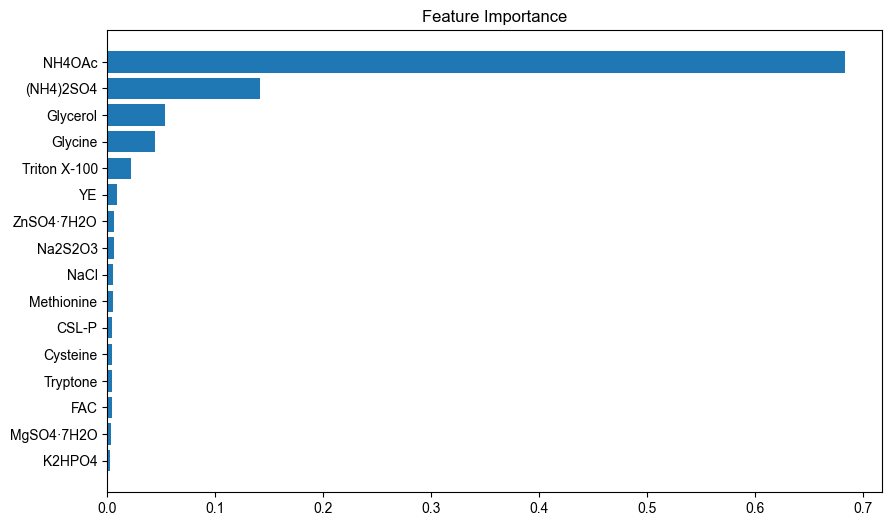

In [18]:
import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
from sklearn.model_selection import train_test_split, KFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from xgboost import plot_importance
from sklearn.inspection import PartialDependenceDisplay, partial_dependence
import seaborn as sns
from scipy.interpolate import splev, splrep


# 划分训练集和测试集
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=RANDOM_SEED,
)

# 超参数随机搜索
model = xgb.XGBRegressor(
    objective="reg:squarederror",
    random_state=RANDOM_SEED,
)
param_grid = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3],
    "colsample_bytree": [0.6, 0.8, 0.9, 1.0],
    "subsample": [0.6, 0.8, 0.9, 1.0],
    "max_depth": [2, 3, 4, 6 , 8],
    "n_estimators": [10, 20,  40, 60, 80, 100, 300, 500],
    "reg_lambda": [1, 1.5, 2],
    "gamma": [0, 0.1, 0.4, 0.6],
    "min_child_weight": [1, 2, 4]
    }   

grid_search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
    n_iter=200,     # 设置为 200 次随机搜索
    random_state=RANDOM_SEED,
)


if LOAD_EXISTING_MODEL and MODEL_PATH.exists():

    best_model = joblib.load(MODEL_PATH)
    model_params = best_model.get_params()
    print(f'已读取已有模型: {MODEL_PATH}')
else:
    grid_search.fit(X_train, y_train)
    best_model = grid_search.best_estimator_
    joblib.dump(best_model, MODEL_PATH)
    print(f'调参完成，最佳模型已保存至: {MODEL_PATH}')



# 测试集预测与 MSE
y_pred = best_model.predict(X_test)
mse = np.mean((y_pred - y_test) ** 2)
print('MSE:', mse)


# 特征重要性
importance = best_model.feature_importances_
sort_importance_and_feature = list(sorted(zip(importance, X.columns), reverse=True))
print('sort_importance_and_feature:', sort_importance_and_feature)
plt.figure(figsize=(10, 6))
plt.barh([x[1] for x in sort_importance_and_feature], [x[0] for x in sort_importance_and_feature])
plt.title('Feature Importance')
plt.gca().invert_yaxis()
plt.savefig(MODELING_OUTPUT_DIR / 'feature_importance.png')
plt.show()

pd.DataFrame(
    sort_importance_and_feature,
    columns=['importance', 'feature'],
).to_csv(MODELING_OUTPUT_DIR / 'importance.csv', index=False)


### 1.2 模型性能评估

分别在训练集和测试集上计算 R²、MSE、RMSE、MAE 与 MAPE，用于比较模型的拟合能力和泛化表现。

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
y_pred_train = best_model.predict(X_train)
y_pred_test = best_model.predict(X_test)

# 计算训练集的评价指标
r2_score_train = best_model.score(X_train, y_train)
mse_train = mean_squared_error(y_train, y_pred_train)
rmse_train = np.sqrt(mse_train)  # 计算RMSE
mae_train = mean_absolute_error(y_train, y_pred_train)
mape_train = np.mean(np.abs((y_train - y_pred_train) / y_train)) * 100

# 计算测试集的评价指标
r2_score_test = best_model.score(X_test, y_test)
mse_test = mean_squared_error(y_test, y_pred_test)
rmse_test = np.sqrt(mse_test)  # 计算RMSE
mae_test = mean_absolute_error(y_test, y_pred_test)
mape_test = np.mean(np.abs((y_test - y_pred_test) / y_test)) * 100

# 打印所有评价指标
print("训练集评价指标：")
print("R2:", r2_score_train)
print("MSE:", mse_train)
print("RMSE:", rmse_train)
print("MAE:", mae_train)
print("MAPE:", mape_train, "%")

print("\n测试集评价指标：")
print("R2:", r2_score_test)
print("MSE:", mse_test)
print("RMSE:", rmse_test)
print("MAE:", mae_test)
print("MAPE:", mape_test, "%")

metrics_df = pd.DataFrame({
    'dataset': ['train', 'test'],
    'R2': [r2_score_train, r2_score_test],
    'MSE': [mse_train, mse_test],
    'RMSE': [rmse_train, rmse_test],
    'MAE': [mae_train, mae_test],
    'MAPE_percent': [mape_train, mape_test],
})
metrics_df.to_csv(MODELING_OUTPUT_DIR / 'model_metrics.csv', index=False)


### 1.3 特征相关性分析

计算全部变量的相关系数矩阵，并绘制仅显示上三角区域的相关性热力图，以观察特征之间及其与目标变量之间的线性相关关系。

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# --- 设置全局字体 ---
plt.rcParams['font.sans-serif'] = ['SimHei', 'DejaVu Sans']
plt.rcParams['font.family'] = ['Times New Roman', 'SimHei']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 14
# --------------------------
corr_matrix=data.corr()

# 增大图形宽度，为右侧颜色条和标签留出更多空间
plt.figure(figsize=(16, 12))

# --- 自定义颜色映射 ---
from matplotlib.colors import LinearSegmentedColormap
custom_cmap = plt.cm.viridis
# ----------------------------------------

# --- 创建上三角mask（遮挡下三角） ---
mask = np.tril(np.ones_like(corr_matrix, dtype=bool), k=-1)  # k=0包含对角线，k=-1保留对角线

# --- 绘制上三角热力图 ---
ax = sns.heatmap(
    corr_matrix,
    annot=True,
    cmap=custom_cmap,
    fmt='.2f',
    annot_kws={"size": 14},
    mask=mask,  # 遮挡下三角，只显示上三角
    # 核心：调整颜色条位置和间距
    cbar_kws={
        "shrink": 1,        # 缩小颜色条高度
        "location": "right",  # 颜色条在右侧
        "pad": 0,          # 颜色条与热力图的间距（增大此值=颜色条右移）
        "aspect": 40,         # 颜色条的长宽比（越大越细长）
        "anchor": (1, 0)  # 颜色条锚点，进一步右移
    },
    square=True,
    linewidths=0.5,
    linecolor='white',
    # 热力图内边距，避免内容太靠边
    yticklabels=True,
    xticklabels=True
)

# --- 调整标签位置 + 解决重叠 ---
# 1. X轴刻度标签移到顶部
ax.xaxis.tick_top()
ax.xaxis.set_label_position('top')
# 2. Y轴刻度标签移到右侧
ax.yaxis.tick_right()
ax.yaxis.set_label_position('right')

# --- 优化Y轴右侧标签 ---
y_ticks = ax.get_yticklabels()
ax.set_yticklabels(
    y_ticks,
    rotation=0,
    ha='left',         # 左对齐，远离热力图
    va='center',       # 垂直居中
    fontsize=14,
    # position=(1, 0) # 水平偏移（1.03=向右偏移3%）
)

# --- 优化X轴顶部标签 ---
x_ticks = ax.get_xticklabels()
ax.set_xticklabels(
    x_ticks,
    rotation=45,
    ha='left',
    va='bottom',
    fontsize=14
)

# --- 调整整体布局，预留右侧空间 ---
plt.subplots_adjust(
    left=0.08,   # 左侧边距
    right=1,  # 右侧边距（减小此值=预留更多右侧空间）
    top=0.92,    # 顶部边距
    bottom=0.08  # 底部边距
)

# --- 标题和最终调整 ---
plt.title('特征相关性热力图', fontsize=16, pad=40)
# # 强制调整布局，避免裁剪
# plt.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])

# 保存图片（高分辨率）
plt.savefig(
    MODELING_OUTPUT_DIR / '特征相关性热力图.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'  # 背景白色
)
plt.show()

### 1.4 真实值与预测值对比

定义回归结果可视化函数，在同一坐标系中展示训练集和测试集的真实值与预测值，并以理想预测线及 R²、RMSE 指标辅助判断模型表现。

In [ ]:



def plot_regression_curve(model, X_train, X_test, y_train, y_test, model_name):
    # Make predictions on training and testing data
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Calculate R², RMSE, and MAE
    r2_train = r2_score(y_train, y_train_pred)
    r2_test = r2_score(y_test, y_test_pred)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_train_pred))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

    # Plot regression curve (with circles for data points)
    plt.scatter(y_train, y_train_pred, label="Train data", alpha=0.7, s=120, facecolors='#1f77b4', edgecolors='black', linewidth=1.5, marker='o')  # Train data
    plt.scatter(y_test, y_test_pred, label="Test data", alpha=0.7, s=120, facecolors='#ff7f0e', edgecolors='black', linewidth=1.5, marker='o')   # Test data

    # Plot ideal y=x line
    plt.plot([min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
            [min(y_train.min(), y_test.min()), max(y_train.max(), y_test.max())],
            'k--', label="y = x", alpha=0.8, linewidth=2)

    # Set title and labels
    plt.title(f"{model_name} Regression Curve", fontsize=18, fontweight='bold', color='#333333')
    plt.xlabel("True Values", fontsize=14, fontweight='bold', color='#555555')
    plt.ylabel("Predicted Values", fontsize=14, fontweight='bold', color='#555555') 

    # Display R², RMSE in the bottom right corner
    plt.text(10, 3, f"Train R²: {r2_train:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#1f77b4')
    plt.text(10, 2, f"Test R²: {r2_test:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#ff7f0e')
    plt.text(10, 1, f"Train RMSE: {rmse_train:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#1f77b4')
    plt.text(10, 0, f"Test RMSE: {rmse_test:.4f}", fontsize=12, verticalalignment='bottom', horizontalalignment='right', color='#ff7f0e')

    # Beautify the plot
    plt.legend(loc="upper left", fontsize=12, fancybox=True, framealpha=0.8, facecolor='white', edgecolor='white', borderpad=1)
    plt.grid(True, which='both', linestyle='--', linewidth=0.8, alpha=0.6, color='#999999')

    plt.savefig(MODELING_OUTPUT_DIR / f'{safe_filename(model_name)}_regression_curve.png', bbox_inches='tight')
    plt.show()

plot_regression_curve(best_model, X_train, X_test, y_train, y_test, 'XGboost')


### 1.5 学习曲线

绘制模型的学习曲线，观察训练样本规模变化对训练与交叉验证性能的影响，为判断欠拟合或过拟合提供依据。

In [ ]:
# import scikitplot as skplt

# skplt.estimators.plot_learning_curve(model, X, y)
# plt.show()

from sklearn.model_selection import LearningCurveDisplay
import numpy as np
import matplotlib.pyplot as plt



def plot_learning_curve(estimator, X, y, scoring="neg_mean_absolute_error"):
    """
    Plot the learning curve for a given estimator.
    """
    LearningCurveDisplay.from_estimator(
        estimator,
        X,
        y,
        train_sizes=np.linspace(0.1, 1.0, 5),
        cv=5,
        scoring=scoring,
        n_jobs=-1,
    )

    plt.title("XGBoost Learning Curve_{scoring}".format(scoring=scoring))
    plt.tight_layout()
    plt.savefig(
        MODELING_OUTPUT_DIR / "learning_curve_{scoring}.png".format(scoring=scoring),
        bbox_inches="tight",
    )
    plt.show()

plot_learning_curve(best_model, X, y, scoring="neg_mean_absolute_error")
plot_learning_curve(best_model, X, y, scoring="r2")

## 2. 部分依赖分析（PDP）

### 2.1 单特征部分依赖图

按照特征重要性排序，逐一计算各特征的一维部分依赖关系；使用样条曲线进行平滑，并叠加样本分布短线后批量保存图像。

In [ ]:

# PDP 超参数：仅作用于本单特征 PDP 程序块。
PDP_GRID_RESOLUTION_1D = 50
PDP_RUG_SAMPLE_SIZE = 100
PDP_SPLINE_SMOOTHING = 30
PDP_INTERPOLATION_POINTS = 300
PDP_X_PADDING_RATIO = 0.10

features = [x[1] for x in sort_importance_and_feature]
for i in features:
    sns.set_theme(style="ticks", palette="deep", font_scale=1.3)
    fig = plt.figure(figsize=(6, 5), dpi=100)
    ax = plt.subplot(111)

    pdp = partial_dependence(best_model, X, [i],
                             kind="average",
                             method='brute',
                             grid_resolution=PDP_GRID_RESOLUTION_1D)

    plot_x = pdp['grid_values'][0]
    plot_y = pdp['average'][0]
    tck = splrep(plot_x, plot_y,
                 s=PDP_SPLINE_SMOOTHING)
    xnew = np.linspace(plot_x.min(), plot_x.max(), PDP_INTERPOLATION_POINTS)
    ynew = splev(xnew, tck, der=0)

    plt.plot(plot_x, plot_y, color='k', alpha=0.5)
    plt.plot(xnew, ynew, linewidth=1.5, linestyle='--')
    sns.rugplot(data=data.sample(min(PDP_RUG_SAMPLE_SIZE, len(data)), random_state=RANDOM_SEED), x=i, height=.06, color='k', alpha=0.3)

    x_min = plot_x.min() - (plot_x.max() - plot_x.min()) * PDP_X_PADDING_RATIO
    x_max = plot_x.max() + (plot_x.max() - plot_x.min()) * PDP_X_PADDING_RATIO
    plt.title('Partial Dependence Plot of ' + i, fontsize=18)
    plt.ylabel('Y')
    plt.xlim(x_min, x_max)
    # 加网格
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(PDP_OUTPUT_DIR / f'pdpplot_{safe_filename(i)}.jpg')
    plt.show()


### 2.2 二维 PDP 依赖项

显式导入 `partial_dependence`，为后续计算两个特征的联合部分依赖关系做准备。

In [ ]:
from sklearn.inspection import partial_dependence

### 2.3 指定特征对的二维部分依赖图

以索引为 0 和 1 的两个特征为示例，计算二维 PDP，并通过填充等高线、等值线和颜色条展示两者对模型预测的联合影响。

In [ ]:

# PDP 超参数：指定本程序块绘制的特征对及二维网格分辨率。
PDP_SELECTED_FEATURE_PAIR = (0, 1)
PDP_GRID_RESOLUTION_2D = 40

# ============================
# 3. 二维部分依赖图 (2D PDP)
# ============================
f1, f2 = PDP_SELECTED_FEATURE_PAIR
# 计算特征 (f1, f2) 的二维 PDP
pdp_2 = partial_dependence(best_model, X=X_train, features=[(f1, f2)], grid_resolution=PDP_GRID_RESOLUTION_2D)
vals_f1, vals_f2 = pdp_2["grid_values"]
Z = pdp_2["average"][0]
XX, YY = np.meshgrid(vals_f2, vals_f1)
# Z = Z.T
plt.figure(figsize=(6,5))
# 填充等高区域
cf = plt.contourf(XX, YY, Z, levels=20, cmap='viridis')
# 绘制等值线
cs = plt.contour(XX, YY, Z, levels=20, colors='k', linewidths=0.8)
# 给等值线添加标注
plt.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
# 设置坐标轴和标题
plt.xlabel(features[f2])
plt.ylabel(features[f1])
plt.title(f"2D PDP — ({features[f1]}, {features[f2]})")
# 添加 colorbar 显示 PDP 数值
plt.colorbar(cf, label="Partial dependence")
plt.tight_layout()
plt.savefig(PDP_OUTPUT_DIR / f"2D_PDP_{safe_filename(features[f1])}_{safe_filename(features[f2])}.png", dpi=600)
plt.show()


### 2.4 全部特征对的二维部分依赖图

枚举所有不重复的特征组合，批量计算并绘制二维 PDP 等高线图，同时将每个特征对的结果保存为高分辨率 PNG 文件。

In [ ]:
# PDP 超参数：本批量二维 PDP 程序块的网格分辨率。
PDP_GRID_RESOLUTION_2D = 40

import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations  # 仅新增这一行导入

# ============================
# 3. 二维部分依赖图 (2D PDP)
# ============================
# 生成所有两两特征的组合（无重复，比如只画(0,1)不画(1,0)）
feature_pairs = combinations(range(len(features)), 2)

# 遍历每一对特征
for f1, f2 in feature_pairs:
    # 计算特征 (f1, f2) 的二维 PDP
    pdp_2 = partial_dependence(best_model, X=X_train, features=[(f1, f2)], grid_resolution=PDP_GRID_RESOLUTION_2D)
    vals_f1, vals_f2 = pdp_2['grid_values']
    Z = pdp_2['average'][0]
    XX, YY = np.meshgrid(vals_f2, vals_f1)
    
    # 修复形状不匹配（仅加这一行）
    if XX.shape != Z.shape:
        Z = Z.T
    
    plt.figure(figsize=(6,5))
    # 填充等高区域
    cf = plt.contourf(XX, YY, Z, levels=20, cmap='viridis')
    # 绘制等值线
    cs = plt.contour(XX, YY, Z, levels=20, colors='k', linewidths=0.8)
    # 给等值线添加标注
    plt.clabel(cs, inline=True, fontsize=8, fmt="%.2f")
    # 设置坐标轴和标题
    plt.xlabel(features[f2])
    plt.ylabel(features[f1])
    plt.title(f"2D PDP — ({features[f1]}, {features[f2]})")
    # 添加 colorbar 显示 PDP 数值
    plt.colorbar(cf, label="Partial dependence")
    plt.tight_layout()
    # 保存图片（避免文件名特殊字符问题，简单替换）
    fname = f"2D_PDP_{safe_filename(features[f1])}_{safe_filename(features[f2])}.png"
    plt.savefig(PDP_OUTPUT_DIR / fname, dpi=600)
    plt.show()


## 3. SHAP 主效应分析

### 3.1 计算 SHAP 值

基于训练完成的树模型创建 `TreeExplainer`，并为完整特征数据计算 SHAP 值，作为后续全局与局部解释的基础。

In [19]:
import shap
from statsmodels.nonparametric.smoothers_lowess import lowess
from matplotlib.ticker import MaxNLocator


# shap分析需要对应的模型以及数据集
explainer = shap.TreeExplainer(best_model) 
# 计算 SHAP 值
shap_values = explainer.shap_values(X)


### 3.2 SHAP 蜂群图与全局重要性组合图

将 SHAP 蜂群分布与平均绝对 SHAP 值条形图组合展示，并计算各特征对总重要性的百分比，输出排序结果并保存图像。

In [20]:
import matplotlib.pyplot as plt
import shap
import numpy as np
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.text import Text

# 仅针对 3.2 模块统一设置字体，确保坐标轴、刻度、颜色条和标注均使用 Arial。
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.sans-serif'] = ['Arial']

# 绘图的 SVG 输出时，确保文本以文本形式保存，以便后续编辑
plt.rcParams["svg.fonttype"] = "none"

# 创建主图（用来画蜂巢图）
fig, ax1 = plt.subplots(figsize=(10, 8), dpi=1200)

# 计算每个特征的平均SHAP值
mean_shap_values = np.abs(shap_values).mean(0)
total_importance = mean_shap_values.sum()
percentages = (mean_shap_values / total_importance) * 100

# 创建特征名称和对应的数值
feature_importance_data = list(zip(columns, mean_shap_values, percentages))
# 按重要性排序
feature_importance_data.sort(key=lambda x: x[1], reverse=True)

# 绘制蜂巢图
shap.summary_plot(shap_values, X, columns, plot_type="dot", show=False, color_bar=True,cmap='viridis')
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整图表位置，留出右侧空间


ax1 = plt.gca()

fig = plt.gcf()  # 获取当前Figure
ax_cbar = fig.axes[-1]  # 获取最后一个轴（颜色条）


# 显式覆盖 SHAP 默认生成的底部横轴标题和颜色条文字。
ax1.set_xlabel(r'$\mathrm{SHAP\ value\ (impact\ on\ predicted\ titer,\ mg/L)}$', fontsize=13)
ax_cbar.set_ylabel(r'$\mathrm{Feature\ value}$', fontsize=12)
ax_cbar.set_yticks(
    ax_cbar.get_yticks(),
    labels=[r'$\mathrm{Low}$', r'$\mathrm{High}$'],
)


# 创建共享 y 轴的另一个图，绘制特征贡献图在顶部x轴
ax2 = ax1.twiny()
shap.summary_plot(shap_values, X, columns, plot_type="bar", show=False,color="#a17fff")
plt.gca().set_position([0.2, 0.2, 0.65, 0.65])  # 调整图表位置，与蜂巢图对齐

# 在顶部 X 轴添加一条横线
y_max = len(columns)
ax2.axhline(y=16, color='black', linestyle='-', linewidth=1)


# 调整透明度
bars = ax2.patches  # 获取所有的柱状图对象
for bar in bars:
    bar.set_alpha(0.2)  # 设置透明度

# 移动顶部的 X 轴，避免与底部 X 轴重叠
ax2.xaxis.set_label_position('top')  # 将标签移动到顶部
ax2.xaxis.tick_top()  # 将刻度也移动到顶部

ax2.set_xlabel(r'$\mathrm{Mean\ absolute\ SHAP\ value}$', fontsize=12)
# 在右侧添加平均SHAP值和百分比文本（按重要性排序）
# 获取当前图中特征的顺序（从上到下）
current_y_labels = [tick.get_text() for tick in ax1.get_yticklabels()]

# 为每个位置添加对应的数值和百分比
for i, feature_name in enumerate(current_y_labels):
    # 找到该特征在排序后数据中的信息
    feature_data = next((item for item in feature_importance_data if item[0] == feature_name), None)
    if feature_data:
        feature, mean_val, percentage = feature_data
        y_pos = i  # 当前特征在图中的y位置
        
        # 分别绘制SHAP值（蓝色）和百分比（红色）
        # 绘制SHAP值（蓝色）
        ax1.text(ax1.get_xlim()[1] * 0.95, y_pos + 0.18, f'{mean_val:.2f}', 
                 verticalalignment='center', fontsize=8, color='blue')
        
        # 绘制百分比（红色）
        ax1.text(ax1.get_xlim()[1] * 0.95, y_pos - 0.18, f'{percentage:.2f}%', 
                 verticalalignment='center', fontsize=8, color='red')


# 设置y轴标签
ax1.set_ylabel(r'$\mathrm{Feature}$', fontsize=12)


plt.grid(False)
plt.tight_layout() 


# 设置ax1的位置
pos = ax1.get_position()
ax1.set_position([
    pos.x0 - 0.06,    # 向左移动
    pos.y0,
    pos.width,
    pos.height
])

# 保存图片
plt.savefig(SHAP_MAIN_OUTPUT_DIR / "SHAP_combined_with_values_and_percentages.png", format='png', bbox_inches='tight', dpi=300)
plt.savefig(SHAP_MAIN_OUTPUT_DIR / "SHAP_combined_with_values_and_percentages.svg", format='svg', bbox_inches='tight')
plt.show()

# 打印特征重要性排序
print("\n特征重要性排序：")
print("特征名\t\t平均SHAP值\t百分比")
print("-" * 40)
for feature, mean_val, percentage in feature_importance_data:
    print(f"{feature}\t\t{mean_val:.4f}\t\t{percentage:.3f}%")


特征重要性排序：
特征名		平均SHAP值	百分比
----------------------------------------
$\mathrm{NH_4OAc}$		39.0824		30.231%
$\mathrm{(NH_4)_2SO_4}$		17.9579		13.891%
$\mathrm{Glycerol}$		16.2475		12.568%
$\mathrm{Glycine}$		14.0031		10.831%
$\mathrm{Triton\ X\text{-}100}$		8.3125		6.430%
$\mathrm{YE}$		6.9550		5.380%
$\mathrm{ZnSO_4}\!\cdot\!\mathrm{7H_2O}$		4.5874		3.548%
$\mathrm{Tryptone}$		3.6405		2.816%
$\mathrm{CSL\text{-}P}$		3.5493		2.745%
$\mathrm{Methionine}$		2.7341		2.115%
$\mathrm{Cysteine}$		2.5591		1.980%
$\mathrm{FAC}$		2.2771		1.761%
$\mathrm{MgSO_4}\!\cdot\!\mathrm{7H_2O}$		2.1704		1.679%
$\mathrm{NaCl}$		1.9854		1.536%
$\mathrm{K_2HPO_4}$		1.6647		1.288%
$\mathrm{Na_2S_2O_3}$		1.5551		1.203%


### 3.3 平均绝对 SHAP 值条形图

按平均绝对 SHAP 值对特征排序，使用渐变色绘制水平条形图，并设置中英文字体、数值标签和坐标轴格式。

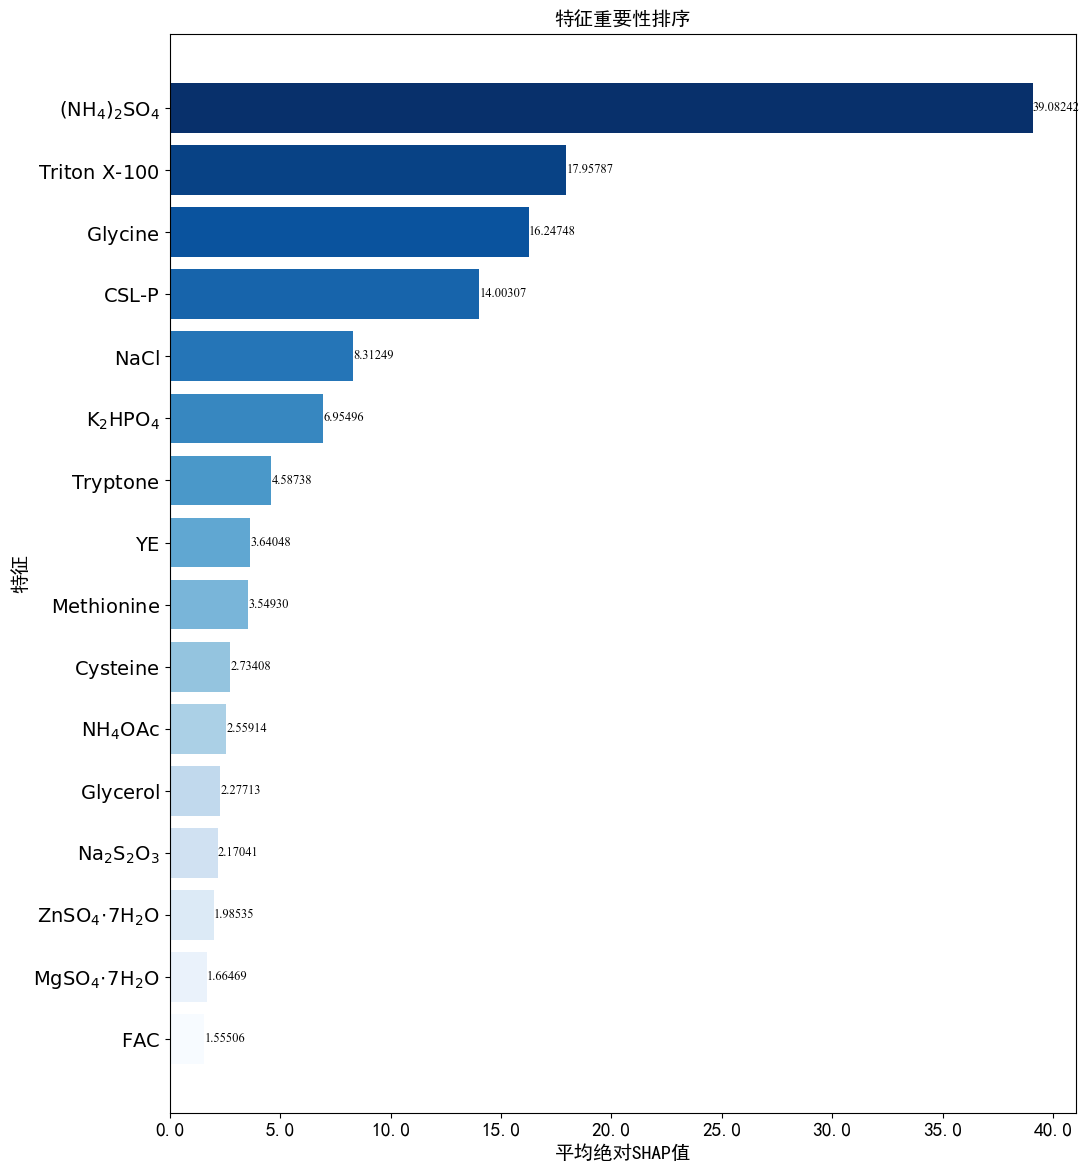

In [21]:
abs_shap_values = np.abs(shap_values)
mean_abs_shap_values = np.mean(abs_shap_values, axis=0)
sorted_indices = np.argsort(mean_abs_shap_values)[::-1]
# sorted_features = X_test.columns[sorted_indices]
sorted_mean_abs_shap_values = mean_abs_shap_values[sorted_indices]

# --- 修改点：调整图形尺寸为 8cm x 12cm ---
# 将厘米转换为英寸 (1 inch = 2.54 cm)
fig_width_cm = 28
fig_height_cm = 30
fig, ax = plt.subplots(figsize=(fig_width_cm / 2.54, fig_height_cm / 2.54))
# ----------------------------------------

# --- 1. 创建从橙色到浅蓝色的渐变色 ---
from matplotlib.colors import LinearSegmentedColormap
# start_color = '#FFB6C1'  # 橙色
# end_color = '#87ceeb'    # 浅蓝色
n_colors = len(columns)
cmap = plt.cm.Blues_r
colors = cmap(np.linspace(0, 1, n_colors))
# ------------------------------------

# --- 2. 绘制条形图 ---
bars = ax.barh(range(len(columns)), sorted_mean_abs_shap_values, align='center', color=colors)
# -------------------

# --- 3. 精细化字体和格式设置 ---
from matplotlib.font_manager import FontProperties
from matplotlib.ticker import FuncFormatter

# 定义字体
font_text = FontProperties(family='SimHei', size=14)  # 中文文字：黑体
font_num = FontProperties(family='Times New Roman', size=14) # 数字：新罗马

# 设置标题和轴标签
ax.set_title('特征重要性排序', fontproperties=font_text, fontsize=14)
ax.set_xlabel('平均绝对SHAP值', fontproperties=font_text, fontsize=14)
ax.set_ylabel('特征', fontproperties=font_text, fontsize=14)

# 设置Y轴特征名称（文字）
ax.set_yticks(range(len(columns)))
ax.set_yticklabels(columns, fontproperties=font_text)

# 设置X轴刻度（数字）为小数点后一位
def format_x_axis(x, pos):
    return f'{x:.1f}'
ax.xaxis.set_major_formatter(FuncFormatter(format_x_axis))
# 应用新罗马字体到X轴和Y轴的刻度数字
ax.tick_params(axis='x', labelsize=12, labelrotation=0)
ax.tick_params(axis='y', labelsize=12)
for label in ax.get_xticklabels():
    label.set_fontproperties(font_text)
for label in ax.get_yticklabels():
    label.set_fontproperties(font_text) # Y轴刻度标签是特征名，用黑体

# 在条形图上添加数值标签（数字用新罗马）
for i, v in enumerate(sorted_mean_abs_shap_values):
    ax.text(v + 0.01, i, f'{v:.5f}', va='center', fontproperties=font_num, fontsize=9)
# ------------------------------------

ax.invert_yaxis()
plt.tight_layout()
plt.savefig(SHAP_MAIN_OUTPUT_DIR / 'mean_absolute_shap_values.png', bbox_inches='tight')
plt.show()


### 3.4 单特征 SHAP 依赖关系与 LOESS 趋势

遍历所有特征，绘制特征取值与对应 SHAP 值的散点图，叠加 LOESS 平滑趋势线及零参考线，并分别导出 PDF。
运行前需要调整固定的Y轴范围

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [38]


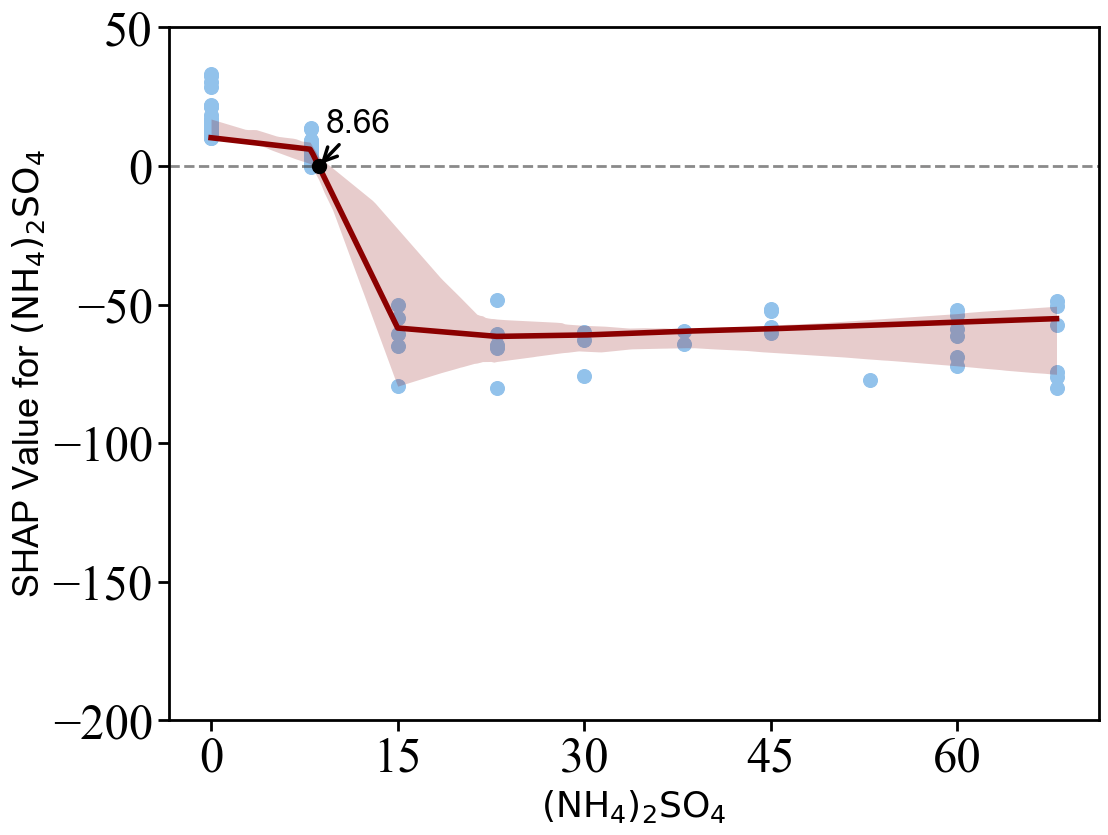

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [86]


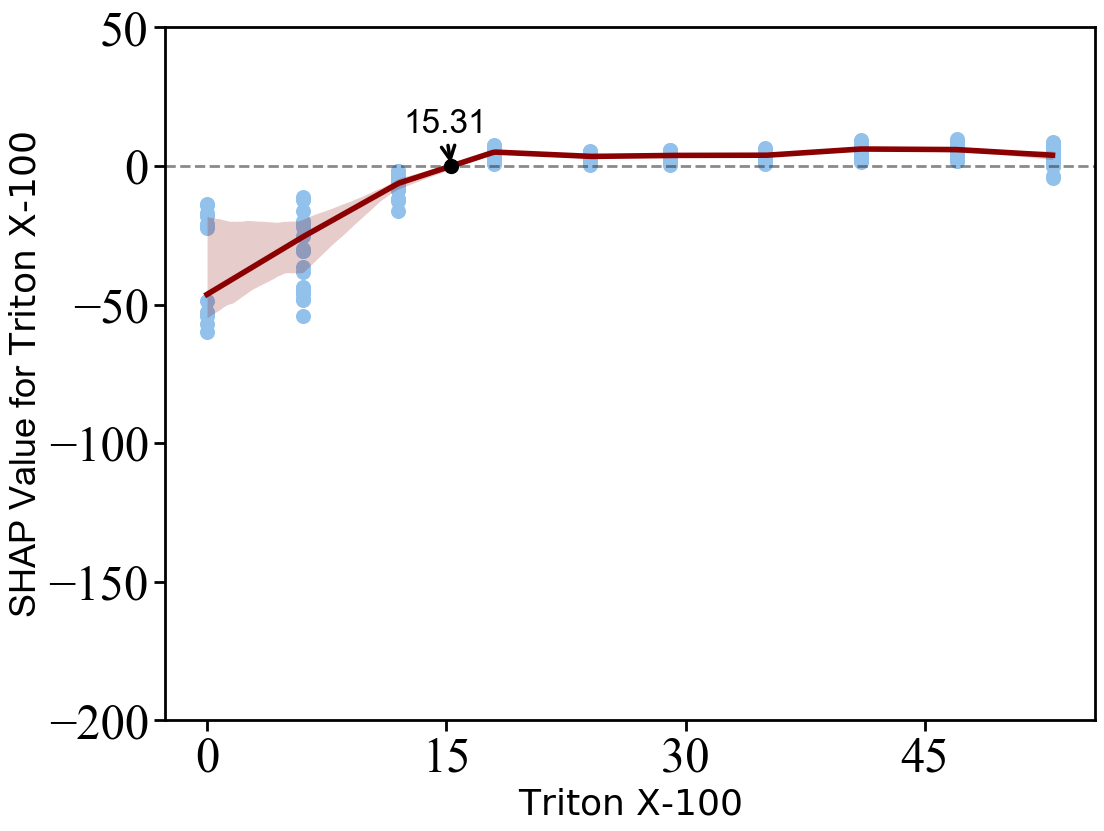

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [187]


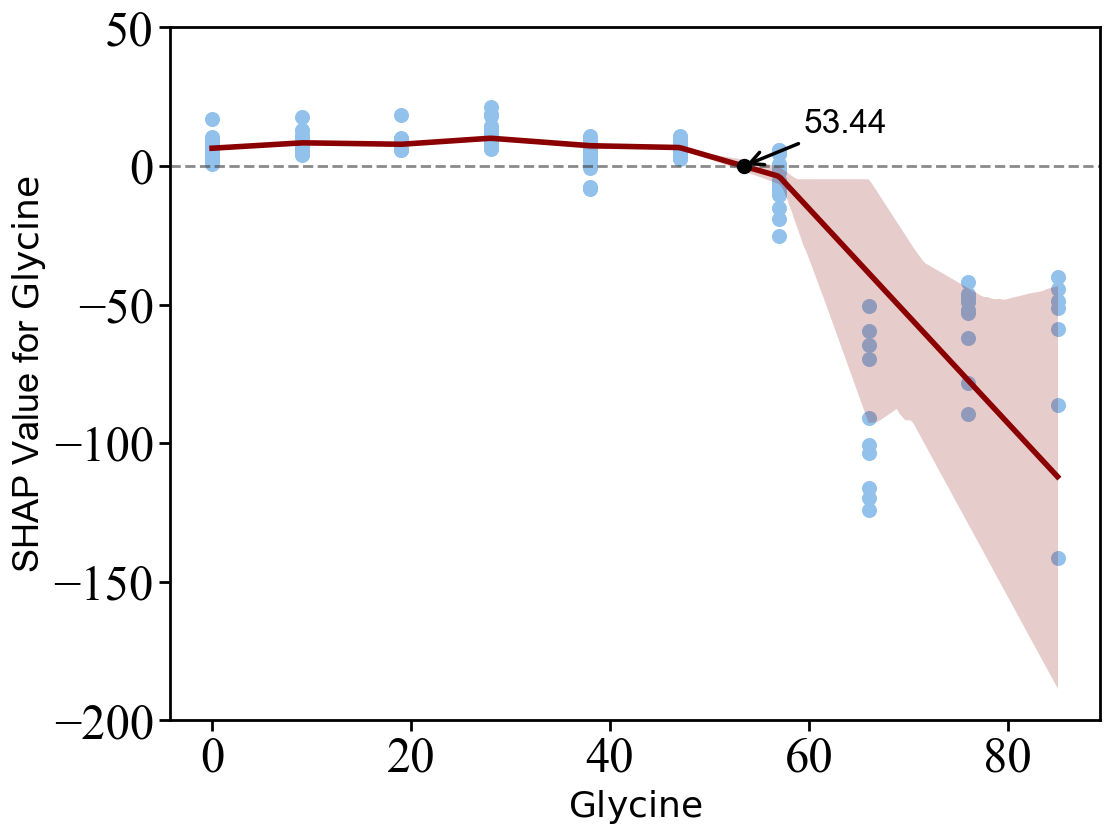

cross_idx: [162]


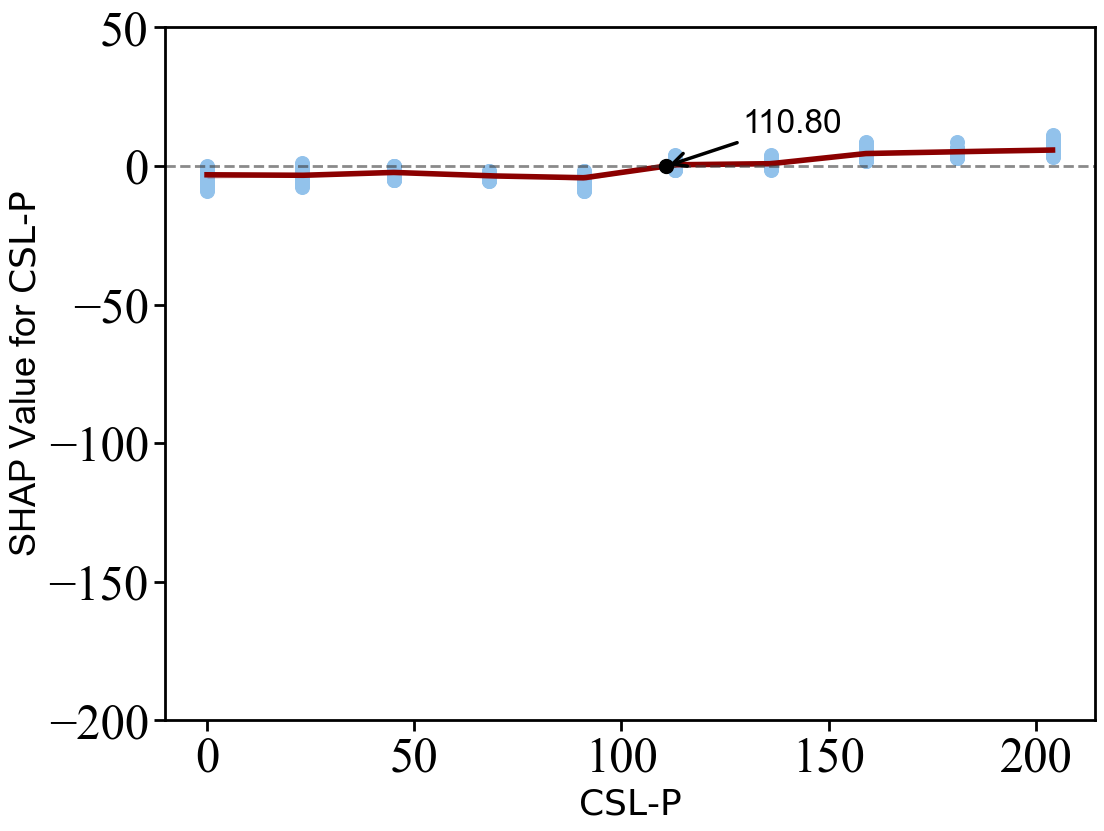

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [181]


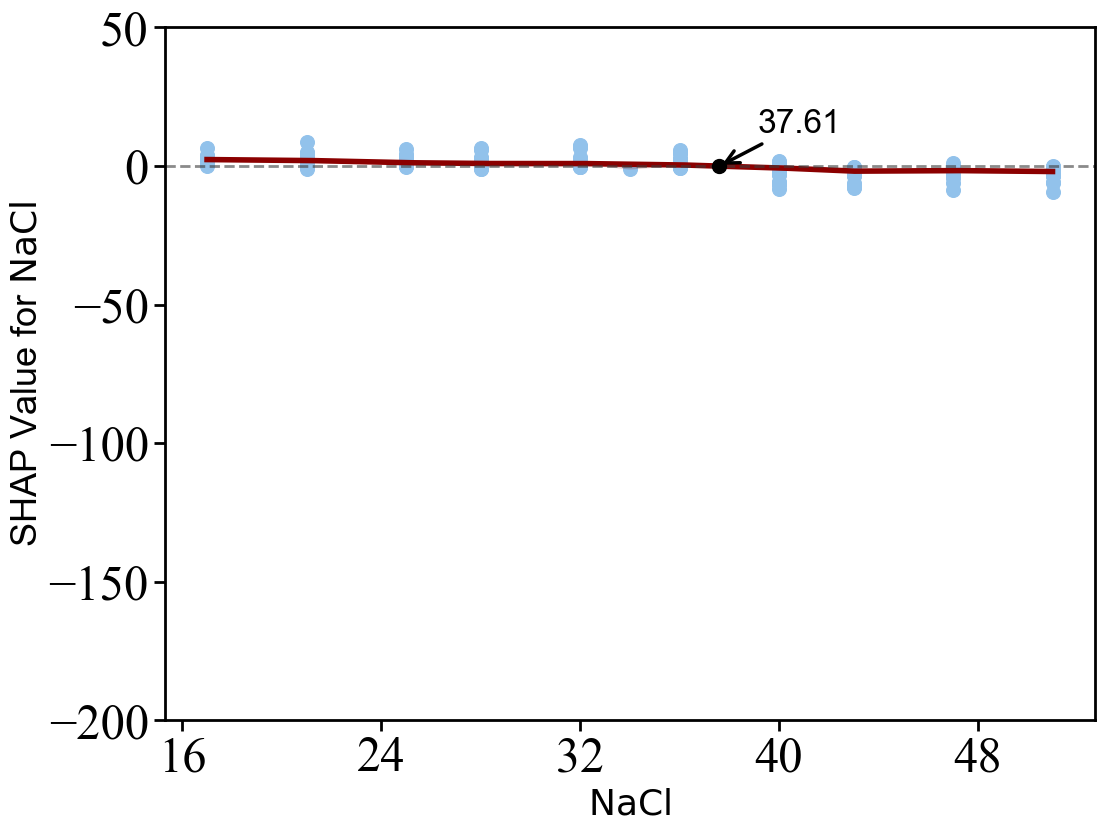

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [ 27 107 199 225 229]


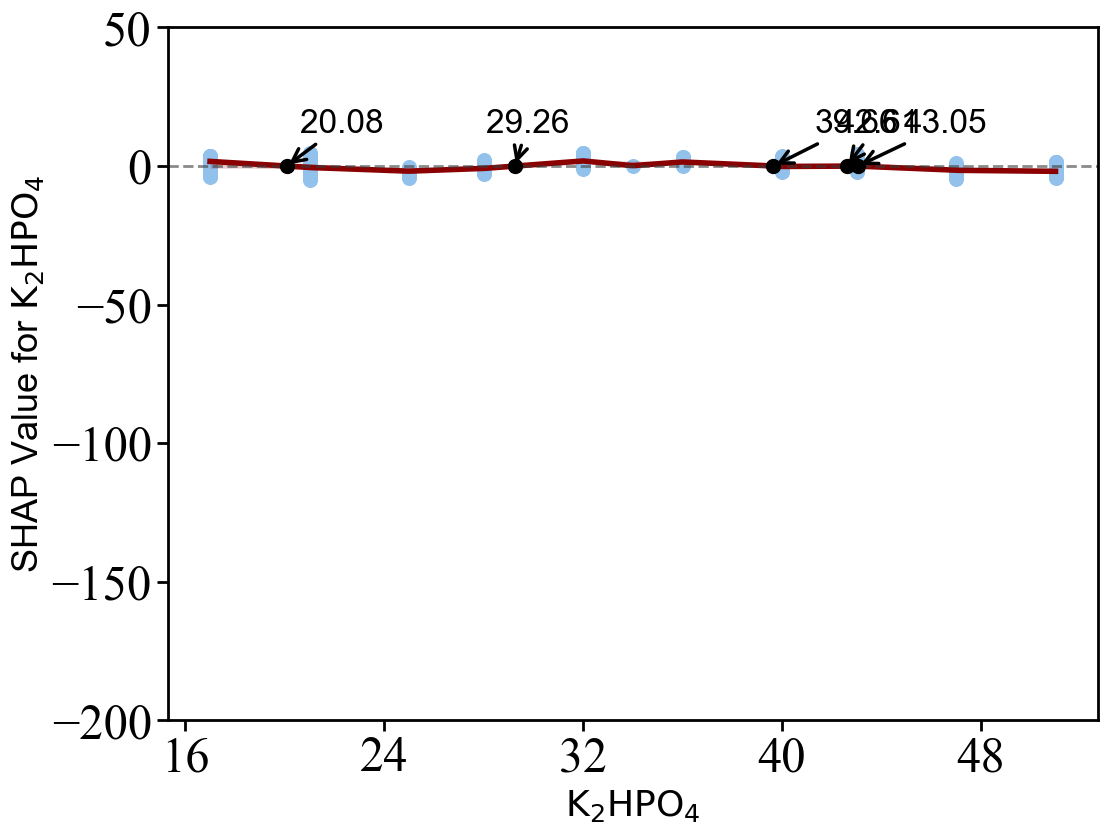

cross_idx: [172]


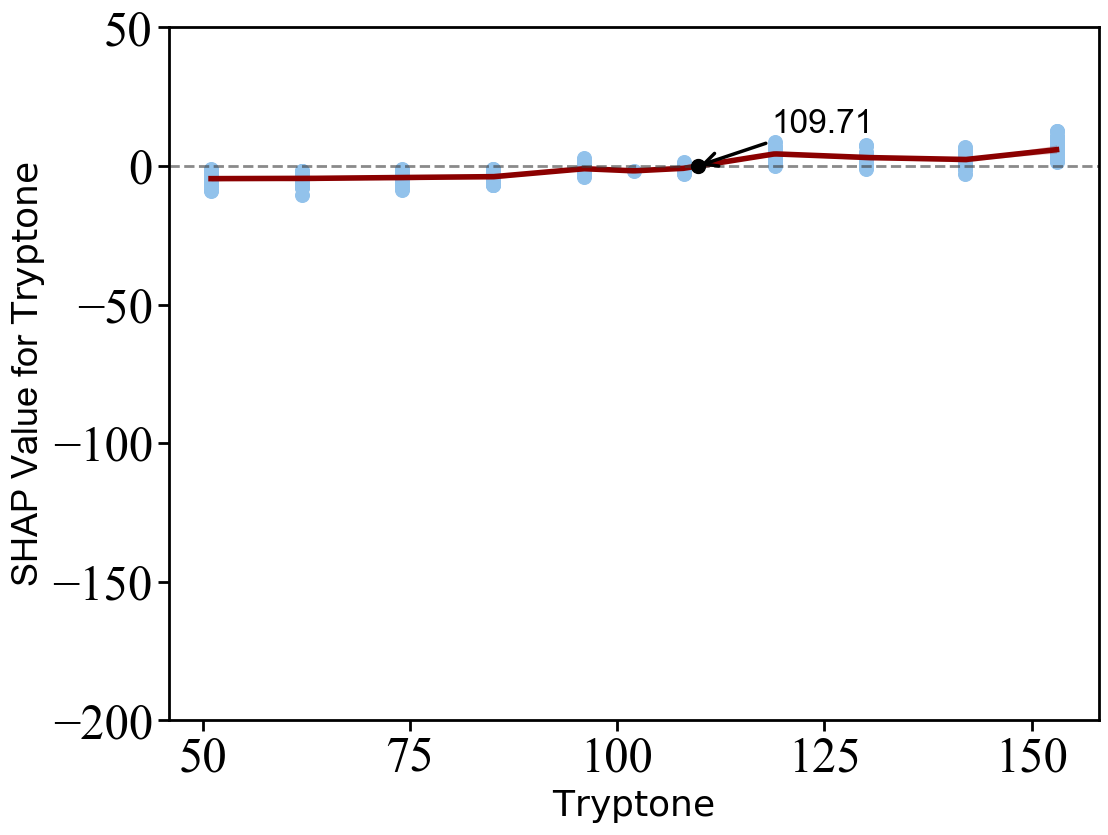

cross_idx: [165]


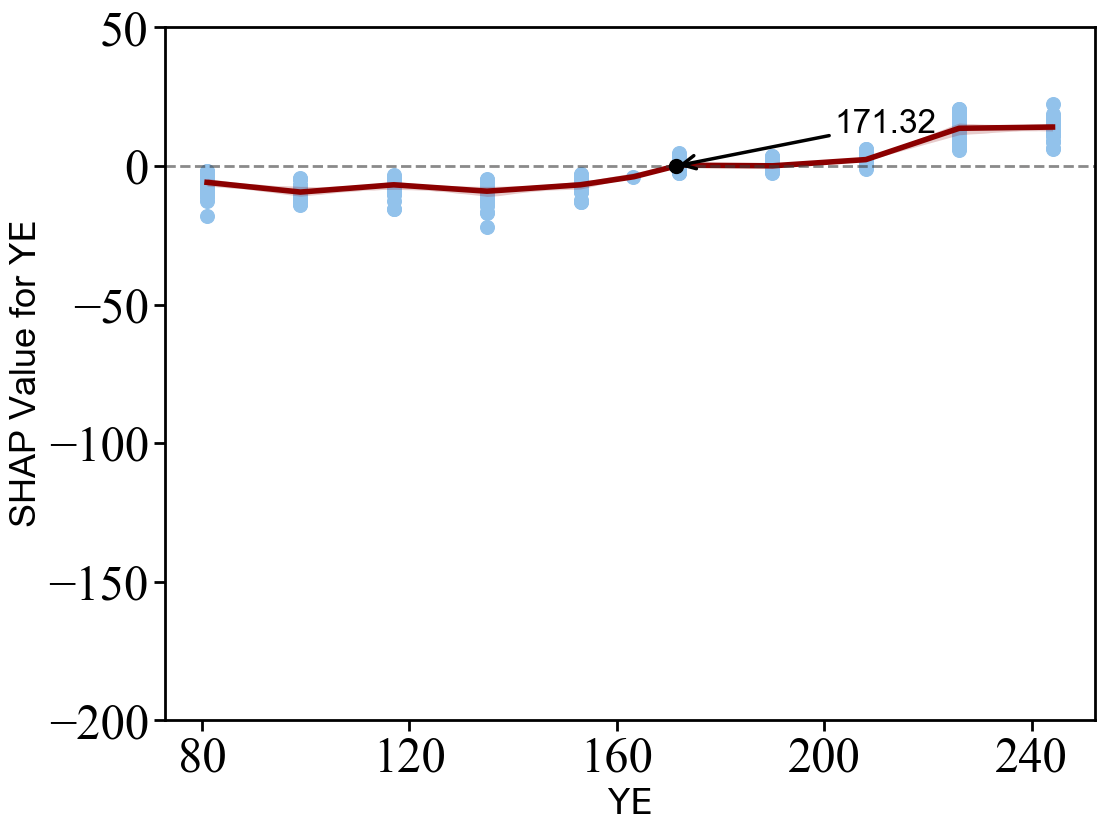

cross_idx: [ 22 239]


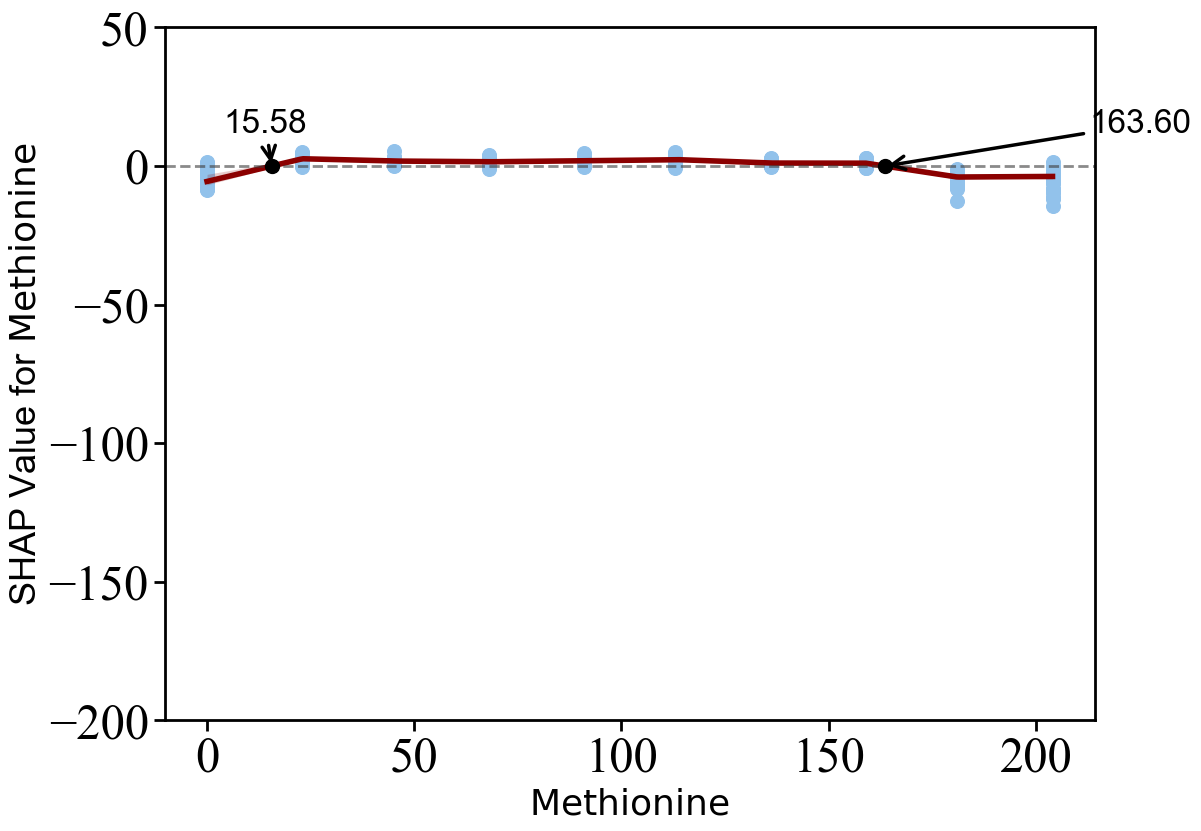

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [129 145 210]


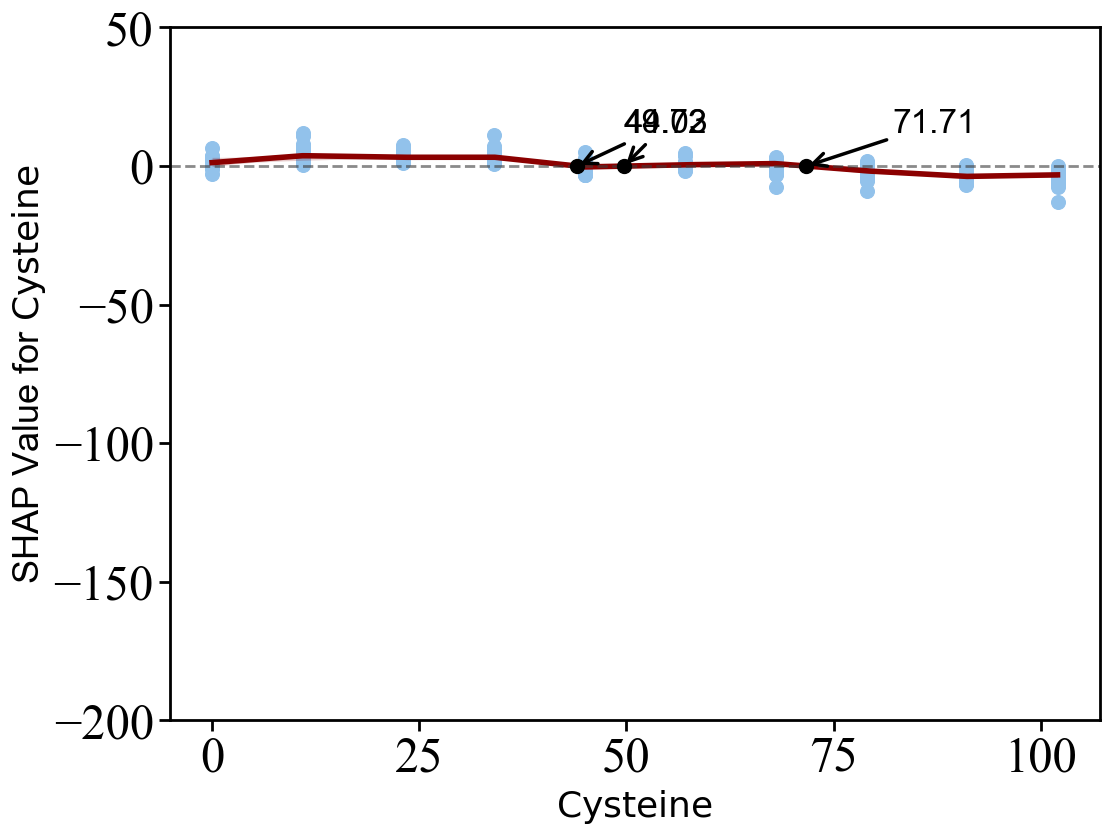

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [36]


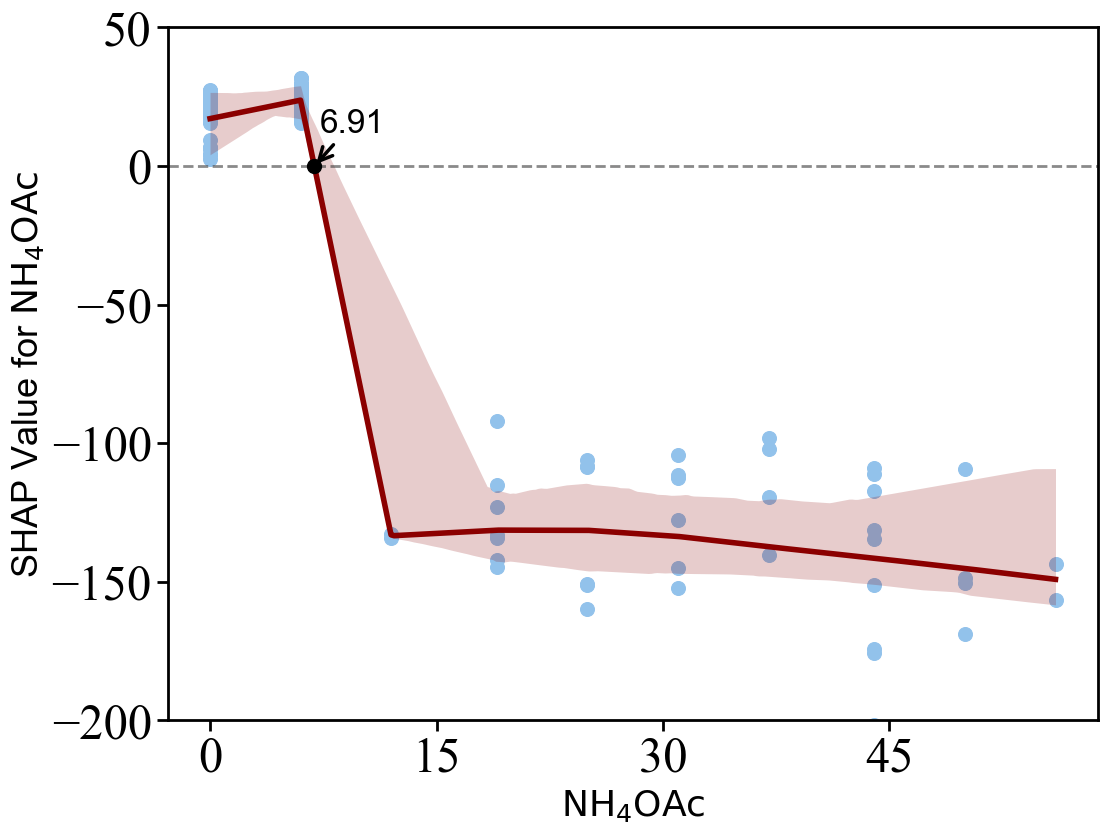

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [149]


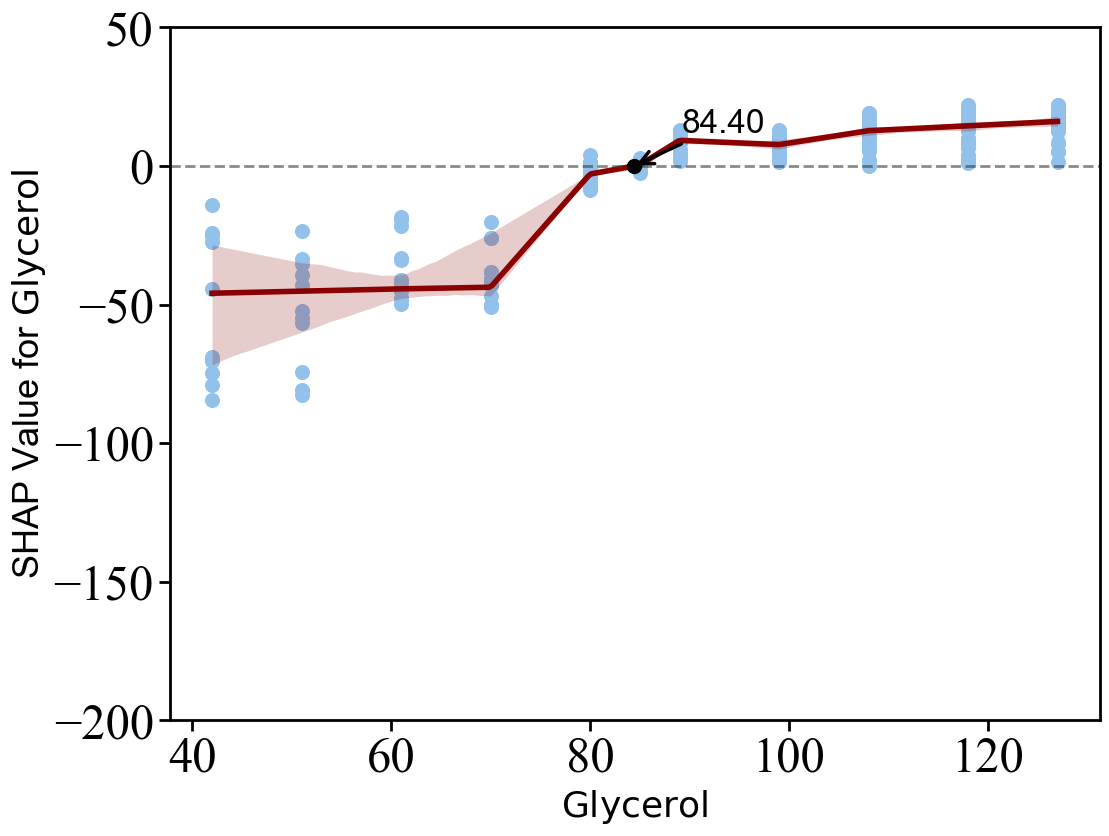

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [ 62 117 139 230 255 268]


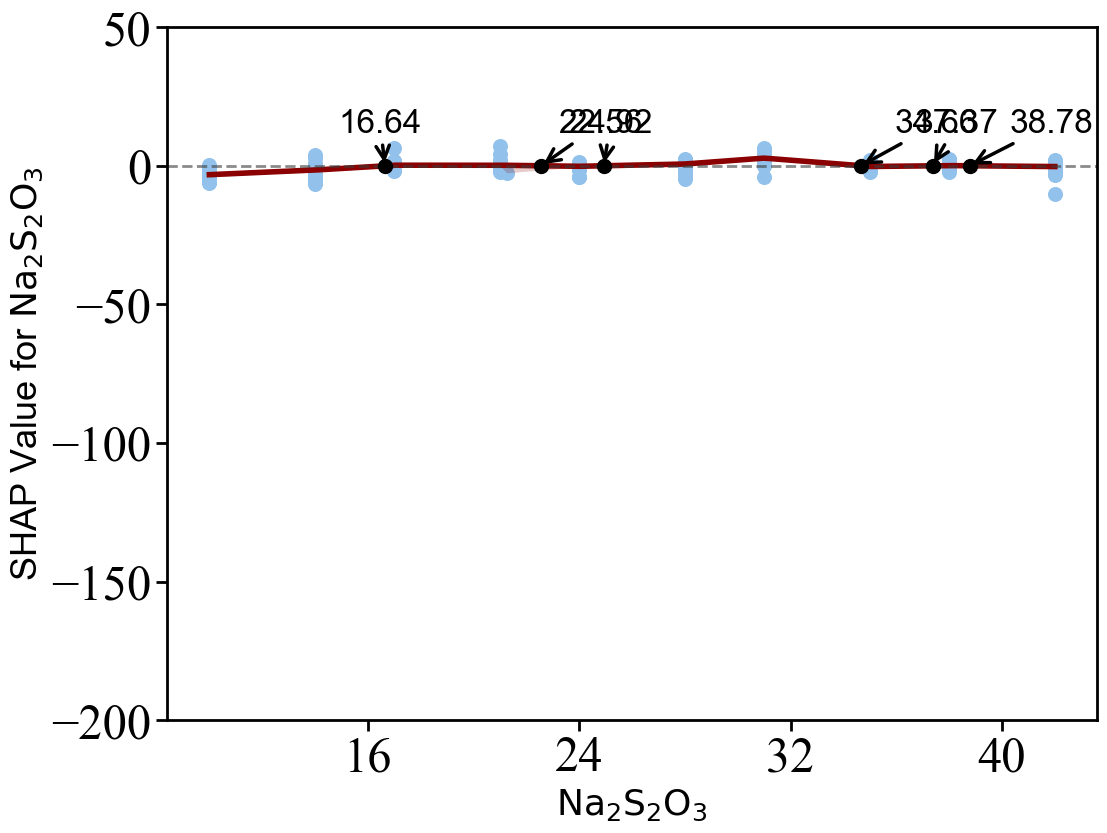

cross_idx: [117]


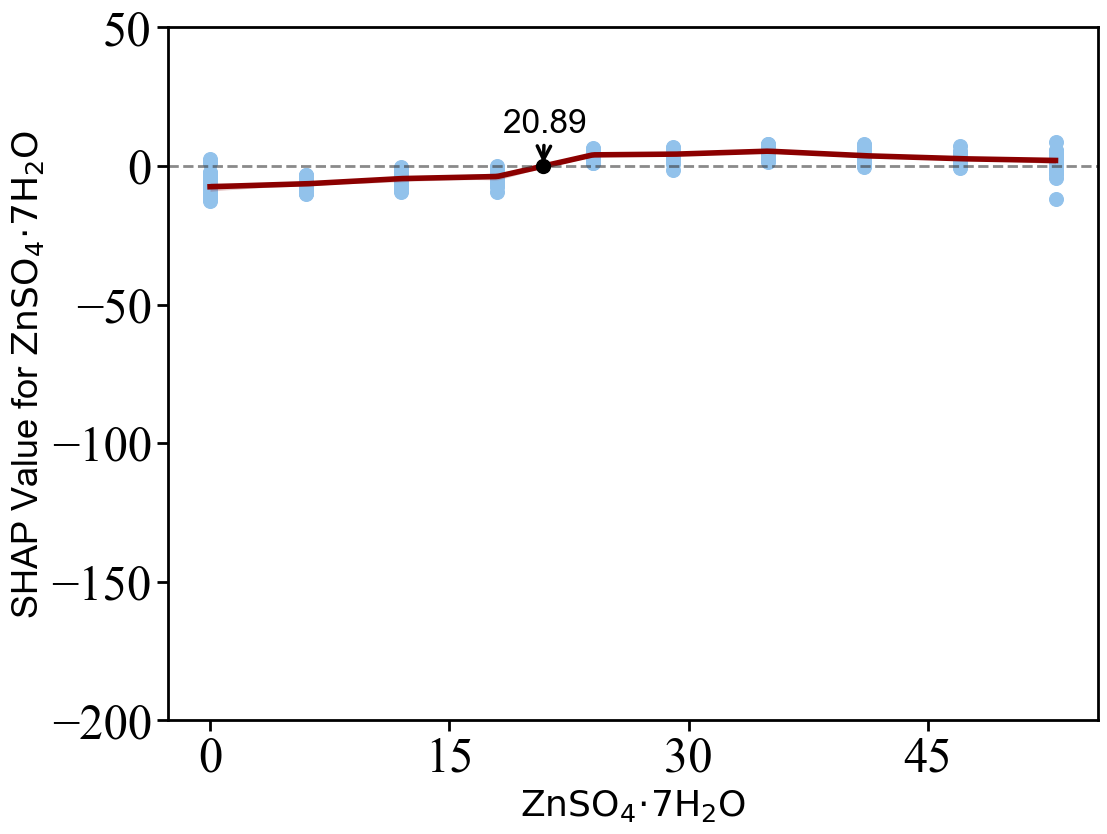

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


cross_idx: [ 27 197]


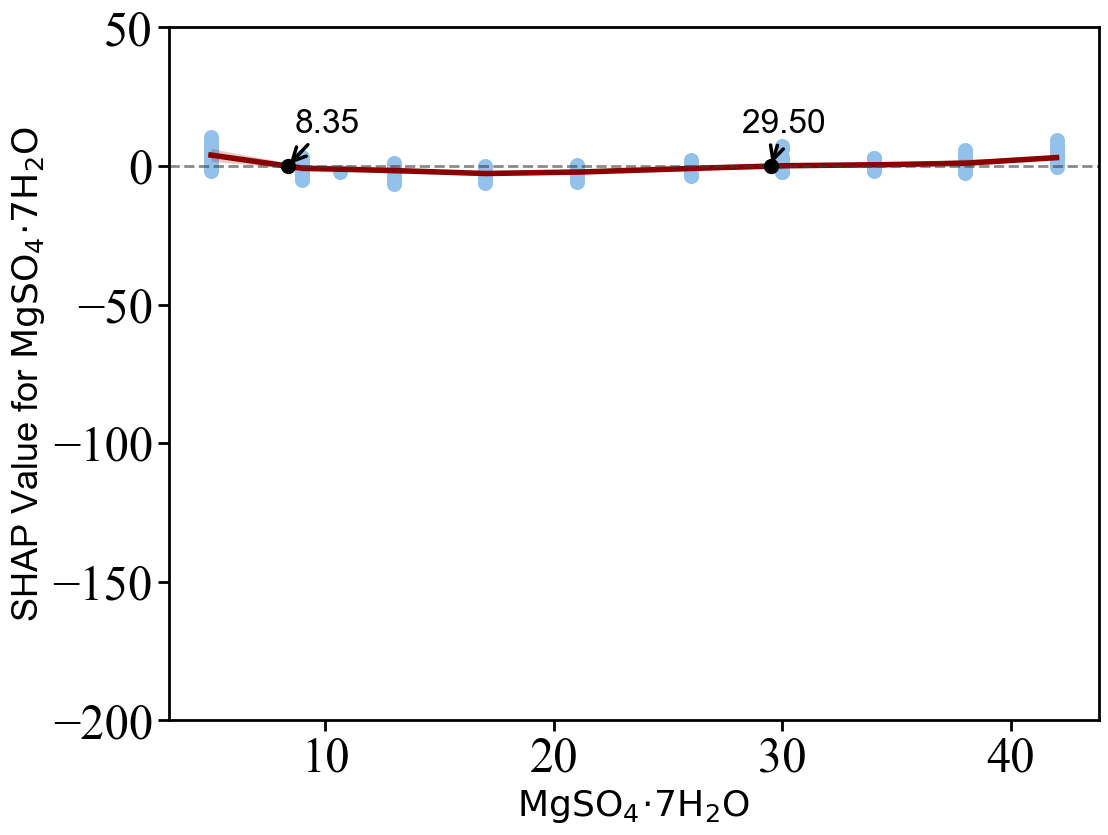

cross_idx: [206]


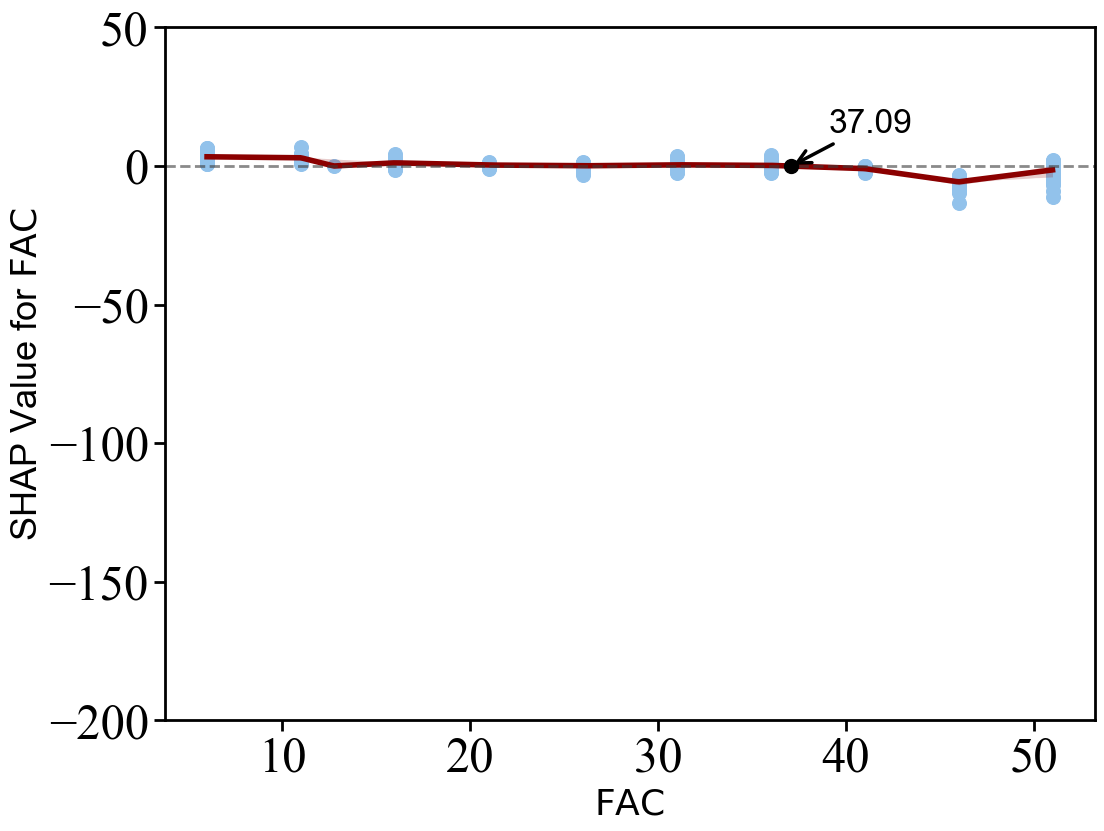

In [22]:
# SHAP 主效应超参数：本依赖关系图的 LOWESS 平滑比例。
SHAP_DEPENDENCE_LOWESS_FRAC = 0.2

from matplotlib.font_manager import FontProperties

# LOESS 置信带与坐标轴设置
LOESS_CONFIDENCE = 0.95       # 置信水平
LOESS_N_BOOTSTRAPS = 200      # bootstrap 次数；越大越稳定，但运行越慢
SHAP_DEPENDENCE_YLIM = (-200.0, 50.0)   # 在这里设置 Y 轴范围，例如：(-5, 1)

rng = np.random.default_rng(RANDOM_SEED)

for i in range(X_train.shape[1]):  # 遍历每个特征
    plt.figure(figsize=(12, 9))
    
    # 确保 SHAP 值是 NumPy 数组
    shap_array = shap_values[:, i]  # 获取第 i 个特征的 SHAP 值
    
    # 画散点图
    sns.scatterplot(x=X.iloc[:, i], y=shap_array, 
                    color='#92C2EB', edgecolor='#92C2EB', s=100)  
    
    # 去除缺失/无穷值，避免影响 LOESS 和置信带计算
    x_values = np.asarray(X.iloc[:, i], dtype=float)
    y_values = np.asarray(shap_array, dtype=float)
    valid_mask = np.isfinite(x_values) & np.isfinite(y_values)
    x_valid = x_values[valid_mask]
    y_valid = y_values[valid_mask]

    # LOESS 曲线
    # 拟合 LOESS 曲线
    loess_result = lowess(y_valid, x_valid, frac=SHAP_DEPENDENCE_LOWESS_FRAC, return_sorted=True)
    x_grid = np.linspace(x_valid.min(), x_valid.max(), 300)
    loess_line = np.interp(x_grid, loess_result[:, 0], loess_result[:, 1])
    # 绘制 LOESS 曲线
    plt.plot(x_grid, loess_line, color='#8B0000', linewidth=4, label='LOESS')


    # 设定置信带的绘制算法：'bootstrap' / 'layered_bootstrap' / 'none'
    confidence_mathod = 'bootstrap'
    if confidence_mathod != 'none':
        # 采用bootstrap方法计算置信带
        if confidence_mathod == 'bootstrap':
            bootstrap_lines = []
            for _ in range(LOESS_N_BOOTSTRAPS):
                sample_idx = rng.integers(0, len(x_valid), len(x_valid))
                boot_result = lowess(
                    y_valid[sample_idx], x_valid[sample_idx],
                    frac=SHAP_DEPENDENCE_LOWESS_FRAC, return_sorted=True
                )
                bootstrap_lines.append(np.interp(x_grid, boot_result[:, 0], boot_result[:, 1]))

            alpha = (1 - LOESS_CONFIDENCE) / 2
            ci_lower, ci_upper = np.quantile(
                np.asarray(bootstrap_lines), [alpha, 1 - alpha], axis=0
            )

        # 采用分层bootstrap方法计算置信带
        if confidence_mathod == 'layered_bootstrap' :
            bootstrap_lines = []
            unique_x = np.unique(x_valid)
            for _ in range(LOESS_N_BOOTSTRAPS):
                boot_x = []
                boot_y = []
                for xv in unique_x:
                    # 找到当前浓度水平对应的所有样本
                    mask = np.isclose(x_valid, xv)
                    x_group = x_valid[mask]
                    y_group = y_valid[mask]
                    # 在该浓度水平内部有放回抽样
                    sample_idx = rng.integers(0,len(y_group),len(y_group))

                    boot_x.extend(x_group[sample_idx])
                    boot_y.extend(y_group[sample_idx])

                boot_x = np.asarray(boot_x)
                boot_y = np.asarray(boot_y)
                # 对该次 bootstrap 数据重新拟合 LOWESS
                boot_result = lowess(boot_y,boot_x,frac=SHAP_DEPENDENCE_LOWESS_FRAC,return_sorted=True)

                # LOWESS 中可能存在重复的 x
                # 对相同 x 的拟合值取平均，便于后续插值
                boot_x_unique = np.unique(boot_result[:, 0])
                boot_y_unique = np.array([np.mean(boot_result[np.isclose(boot_result[:, 0], xv),1])
                    for xv in boot_x_unique])

                # 插值到统一的 x_grid
                boot_line = np.interp(x_grid,boot_x_unique,boot_y_unique)
                bootstrap_lines.append(boot_line)

            alpha = (1 - LOESS_CONFIDENCE) / 2
            ci_lower, ci_upper = np.quantile(
                np.asarray(bootstrap_lines),[alpha, 1 - alpha],axis=0
            )


        # 绘制置信带
        plt.fill_between(x_grid, ci_lower, ci_upper, color='#8B0000', alpha=0.20,
                            linewidth=0, label=f'{LOESS_CONFIDENCE:.0%} CI')


    # 绘制零参考线
    plt.axhline(y=0, color="#3D3C3C", linestyle='--', linewidth=2, alpha=0.6)


    # 绘制LOESS曲线与y=0的交点
    cross_idx = np.where(np.diff(np.sign(loess_line)) != 0)[0]
    print('cross_idx:', cross_idx)
    for idx in cross_idx:
        x1, x2 = x_grid[idx], x_grid[idx + 1]
        y1, y2 = loess_line[idx], loess_line[idx + 1]
        x_zero = x1 - y1 * (x2 - x1) / (y2 - y1)
        if y1-y2 >= 0 :
            xytext = (x_zero+20, 30)
        else:
            xytext = (x_zero-20, 30)
        plt.scatter(x_zero, 0, color='black', s=100, zorder=10)
        plt.annotate(f'{x_zero:.2f}', xy=(x_zero, 0), xytext=xytext,
                     textcoords='offset points', ha='center',va='center', fontsize=24,
                     arrowprops=dict(arrowstyle='->', color='black',linewidth=2.5,))   

    # 轴标签
    plt.xlabel(columns[i], fontsize=26, family='Arial')  
    plt.ylabel(f'SHAP Value for {columns[i]}', fontsize=26, family='Arial')  
    
    # 调整刻度参数
    plt.tick_params(axis='both', which='both', labelsize=34, labelcolor='black', 
                    direction='out', length=8, width=2)


    # 设置横坐标刻度个数为 5
    ax = plt.gca()
    ax.xaxis.set_major_locator(MaxNLocator(nbins=5))
    if SHAP_DEPENDENCE_YLIM is not None:
        ax.set_ylim(*SHAP_DEPENDENCE_YLIM)

    # 让刻度数字的字体变大
    font_properties = FontProperties(family='Times New Roman', size=35)
    for label in plt.gca().get_xticklabels() + plt.gca().get_yticklabels():
        label.set_fontproperties(font_properties)

    # 加深边框颜色并加粗
    for spine in ax.spines.values():
        spine.set_edgecolor('black')  # 使边框变黑
        spine.set_linewidth(2)  # 增加边框厚度

    # 清除默认图例
    if ax.get_legend() is not None:
        ax.get_legend().remove()

    plt.savefig(SHAP_MAIN_OUTPUT_DIR / f'shap_dependence_plot_{safe_filename(X.columns.values[i])}.svg', bbox_inches='tight')

    # 绘图    
    plt.show()

    


   

### 3.5 SHAP 值表格化

将 SHAP 数组转换为以原始特征名为列名的 DataFrame，便于后续按特征提取、筛选和绘图。

In [23]:
shap_values_df=pd.DataFrame(shap_values,columns=rawcolumns)
shap_values_df.to_csv(SHAP_MAIN_OUTPUT_DIR / 'shap_values.csv', index=False)


### 3.6 指定特征的精细 SHAP 依赖图

以 `LSTAT` 为主特征、`B` 为着色特征，清洗有效数据后绘制 SHAP 散点及分布信息，并结合平滑、阈值和颜色映射生成精细依赖图。

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


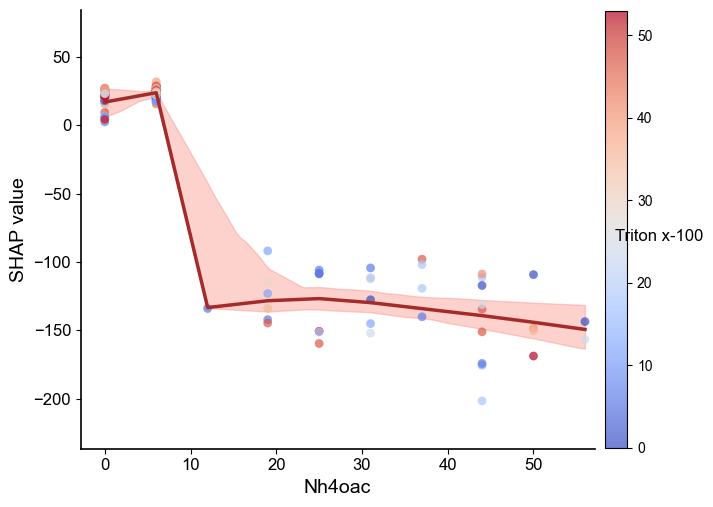

In [24]:
# SHAP 主效应超参数：指定特征精细依赖图。
SHAP_FEATURE_TO_PLOT = "NH4OAc"
SHAP_COLOR_FEATURE = "Triton X-100"
SHAP_DETAIL_LOWESS_FRAC = 0.40
SHAP_BOOTSTRAP_SAMPLES = 100
SHAP_CI_LEVEL = 0.95
SHAP_CI_LOWER_PERCENTILE = (1 - SHAP_CI_LEVEL) * 50
SHAP_CI_UPPER_PERCENTILE = 100 - SHAP_CI_LOWER_PERCENTILE

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from numpy.polynomial.polynomial import Polynomial
from matplotlib.colors import LinearSegmentedColormap  # 导入自定义颜色映射所需的库
import matplotlib.cm as cm  # 导入cm模块

# 选择的特征
feature_to_plot = SHAP_FEATURE_TO_PLOT#我们给 'age' 这个名字贴上了这个标签
# 这里可以替换为其他特征名，如 'cholesterol', 'blood_pressure' 等
feature_to_color = SHAP_COLOR_FEATURE

# 提取数据
X_data_orig = X[feature_to_plot].values#从一个名为 `X_test` 的数据集中，把所有 ‘age’ 这一列始数取出来

Y_data_orig = shap_values_df[feature_to_plot].values#从一个名为 `shap_values_df` 的数据集中，也把 ‘age’ 这一列的数值提取出来
color_data_orig = X[feature_to_color].values


# 过滤NaN/Inf
valid_indices_orig = np.isfinite(X_data_orig) & np.isfinite(Y_data_orig) & np.isfinite(color_data_orig)
#np.isfinite() 会检查每个数据点是不是一个正常的、有限的数字
# 所以这行代码的意思是：“__只有当一个数据点的年龄值和它的SHAP值都是正常数字时，我们才认为它是有效
X_data = X_data_orig[valid_indices_orig]
Y_data = Y_data_orig[valid_indices_orig]
color_data = color_data_orig[valid_indices_orig]

if len(X_data) < 2:
    print(f"特征 '{feature_to_plot}' 的有效数据点不足以绘图。")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.text(0.5, 0.5, f"数据不足: {feature_to_plot}", ha='center', va='center')
    plt.show()
    import sys
    sys.exit()

# LOWESS 拟合 
lowess_frac = SHAP_DETAIL_LOWESS_FRAC
# frac参数控制LOWESS平滑的程度，0.4表示使用40%的数据点进行局部加权回归
# 值越小，曲线就越“贴近”每一个数据点，可能会显得很曲折
# 值越大，曲线就越平滑，可能会忽略一些局部变化
# 0.4意味着算法在计算曲线上某一点时，会参考它周围 40% 的数据点
# 这是一个经验性的选择，用来平衡曲线的平滑度和对数据的拟合度

sort_idx_main = np.argsort(X_data) # 把“年龄”从小到大排队，返回一张“排队顺序表”（索引表）
X_sorted_main = X_data[sort_idx_main]
Y_sorted_main = Y_data[sort_idx_main]# 按刚才的顺序表，把“年龄”和对应的 SHAP 值重新排好队，方便后面画线时不乱

r_squared_lowess = np.nan
# 先给“LOWESS 曲线的拟合优度”留个空盒子，后面算出来再填
# R²（拟合优度）就是 评分卡：
# 0 分表示曲线跟瞎猜没区别，1 分表示曲线完美穿过所有豆子
# 0.5 分表示曲线大致跟豆子走向一致，但有
# 一些豆子偏离曲线
# 这个分数写在论文里，别人一看就知道模型解释力好不好
lowess_interpolation_function = None
# 先给“LOWESS 插值函数”留个空盒子，后面算出来再填
# 插值函数更像 一把“刻度尺”
# 你把任意年龄输进去，它立刻告诉你对应曲线上的 y 值
main_lowess_fit_points = None
# 先给“LOWESS 拟合点”留个空盒子，后面算出来再填
# LOWESS 先在这些豆子之间 插一条光滑的曲线
# 这条曲线由很多“点”组成——每隔一小段 x 就取一个 y，这些 (x, y) 就叫 拟合点

# LOWESS拟合
main_lowess_fit_points = lowess(Y_sorted_main, X_sorted_main, frac=lowess_frac, it=0)
# 阶段1：初始拟合（it=0时只执行此阶段）
# 对每个数据点x_i，确定其邻域内的点
# 基于距离计算权重：距离x_i越近的点权重越高
# 用加权最小二乘法拟合局部多项式回归
# 当it=3（默认值）时，算法会执行以下迭代
# 第一次迭代：

# 计算残差 = 实际值 - 拟合值
# 识别异常值（残差特别大的点）
# 降低异常值的权重（使用bisquare权重函数）
# 重新拟合，减少异常值影响
# 后续迭代：

# 重复上述过程3次
# 每次迭代都进一步降低异常值权重
# 最终得到对异常值不敏感的平滑曲线
plot_main_lowess = True

# 生成唯一的X值对应的Y值
unique_x_lowess, unique_indices = np.unique(main_lowess_fit_points[:, 0], return_index=True)
# 这行代码的作用是：从LOWESS拟合的结果中提取唯一的X值，并返回这些唯一值在原数组中的索引
# main_lowess_fit_points[:, 0]指的是LOWESS拟合结果中的X值列
# 这是因为main_lowess_fit_points是一个二维数组，其中第一列是X值，第二列是对应的Y值
# unique_x_lowess将包含所有唯一的X值，而unique_indices将包含这些唯一X值在原数组中的索引
# 这样做的目的是为了后续处理时只保留每个唯一X值对应的第一个Y值
# 这可以帮助我们在绘图时避免重复的X值，从而使曲线更加清晰
y_for_unique_x_lowess = main_lowess_fit_points[unique_indices, 1]
# 这行代码的作用是：从LOWESS拟合结果中提取唯一X值对应的Y值
# unique_indices是之前得到的唯一X值在原数组中的索引
# main_lowess_fit_points中索引0列是X值，索引1列是Y值
# 通过unique_indices，我们可以获取每个唯一X值对应的第一个Y值
if len(unique_x_lowess) > 1:
    lowess_interpolation_function = interp1d(unique_x_lowess, y_for_unique_x_lowess,
                                             kind='linear', fill_value="extrapolate")
# 这行代码的作用是：创建一个线性插值函数
# interp1d是SciPy库中的一个函数，用于创建一维插值函数
# unique_x_lowess是唯一的X值，y_for_unique_x_lowess是对应的Y值
# kind='linear'表示使用线性插值方法
# fill_value="extrapolate"表示如果查询的X值超出范围，则使用外推法来计算Y值
# 这样，我们就可以使用lowess_interpolation_function来查询任意X值对应的Y值
# extrapolate会让工具查看最后一段已知的趋势（比如从12点到3点的温度变化趋势），给出一个猜测值

# 计算R²值
if lowess_interpolation_function:
    y_pred_for_r2 = lowess_interpolation_function(X_sorted_main)
# 这行代码的作用是：使用之前创建的插值函数lowess_interpolation_function来计算X_sorted_main中每个X值对应的Y值
# 这样，我们就得到了一个预测的Y值数组y_pred_for_r2
# 如果lowess_interpolation_function不存在（可能是因为数据点太少），则使用线性插值
# 否则会报错，所以我们需要检查lowess_interpolation_function是否存在
else:
    temp_interp = interp1d(main_lowess_fit_points[:, 0], main_lowess_fit_points[:, 1], fill_value="extrapolate", kind='linear')
    y_pred_for_r2 = temp_interp(X_sorted_main)
# 这行代码的作用是：使用线性插值函数temp_interp来计算X_sorted_main中每个X值对应的Y值
# fill_value="extrapolate"表示如果查询的X值超出范围，则使用外推法来计算Y值
# kind='linear'表示使用线性插值方法

y_true_for_r2 = Y_sorted_main
ss_res = np.sum((y_true_for_r2 - y_pred_for_r2)**2)
ss_tot = np.sum((y_true_for_r2 - np.mean(y_true_for_r2))**2)
# 计算R²值
# ss_res是残差平方和，表示预测值与实际值之间的差异
# ss_tot是总平方和，表示实际值与其均值之间的差异
# R²值的计算公式为：1 - (ss_res / ss_tot)
if ss_tot < np.finfo(float).eps:# 检查总平方和是否接近于0
    # 如果总平方和接近于0，说明数据点几乎没有变化
    r_squared_lowess = 1.0 if ss_res < np.finfo(float).eps else 0.0
# 如果总平方和接近于0，说明数据点几乎没有变化
# 在这种情况下，我们可以认为LOWESS拟合完美（R²=1）
# 如果残差平方和也接近于0，说明预测值与实际值几乎完全一致
# 否则，R²值为0，表示LOWESS拟合没有解释数据
else:
    r_squared_lowess = 1.0 - (ss_res / ss_tot)


# LOWESS拟合的置信区间 (Bootstrapping) 
n_bootstraps = SHAP_BOOTSTRAP_SAMPLES  # 设置Bootstrap采样次数
# Bootstrap是一种重采样技术，通过对原始数据集进行有放回的随机抽样，生成多个"伪数据集"（Bootstrap样本），用于：
# 估计统计量的分布
# 计算置信区间
# 评估模型稳定性
# 设置随机种子以保证可复现性
random_seed = RANDOM_SEED  # 设置随机种子以保证可复现性
np.random.seed(random_seed)  # 固定随机种子
# 这行代码的作用是：设置NumPy的随机种子为42
# 这样做的目的是为了确保每次运行代码时生成的随机数序列都是相同的
# 这对于调试和结果复现非常重要，因为随机数生成器在每次运行时都会生成不同的随机数
# 通过设置随机种子，我们可以确保每次运行代码时，Bootstrap采样和其他随机操作的结果都是一致的

# 设置置信区间的范围
x_min_plot_ci, x_max_plot_ci = (X_data.min(), X_data.max()) if len(X_data) > 0 else (0, 1)
# 计算置信区间的X值范围
# 这行代码的作用是：计算X_data的最小值和最大值
# 如果X_data中有数据点，则使用其最小值和最大值
# 否则，默认范围为0到1
x_smooth_for_ci = np.linspace(x_min_plot_ci, x_max_plot_ci, 100)
# 生成平滑的X值，用于绘制置信区间
# 这行代码的作用是：生成一个从x_min_plot_ci到x_max_plot_ci的平滑X值序列
# linspace函数会在这个范围内生成100个等间距的点

boot_lowess_preds = []  # 存储每次Bootstrap采样的LOWESS预测
# 初始化一个空列表，用于存储每次Bootstrap采样的LOWESS预测结果
# 这个列表会在后续的Bootstrap循环中被填充
plot_ci = False  # 初始化置信区间绘制标记
# 初始化置信区间绘制标记为False
# 这个标记用于控制是否绘制LOWESS的置信区间

# 如果数据点大于1并且启用了LOWESS绘制
if len(X_data) > 1 and plot_main_lowess:# 如果数据点大于1并且启用了LOWESS绘制
    for i in range(n_bootstraps):
        # 进行有放回的随机采样
        indices = np.random.choice(len(X_data), len(X_data), replace=True)
        # 这行代码的作用是：从0到len(X_data)-1之间随机选择len(X_data)个索引
        # replace=True表示允许重复选择同一个索引
        # 这样可以模拟Bootstrap采样，即从原始数据中有放回地抽取样本
        # 这会生成一个长度为len(X_data)的索引数组indices
        X_boot, Y_boot = X_data[indices], Y_data[indices]
        # 根据随机索引从原始数据中抽取Bootstrap样本
        # 这行代码的作用是：使用随机索引indices从X_data和Y_data中抽取样本
        # X_boot将包含Bootstrap采样后的特征值，Y_boot将包含对应的SHAP值

        # 排序数据
        sort_idx_boot = np.argsort(X_boot)
        X_boot_sorted, Y_boot_sorted = X_boot[sort_idx_boot], Y_boot[sort_idx_boot]
        # 这行代码的作用是：对X_boot进行排序，并返回排序后的索引
        # np.argsort(X_boot)会返回一个索引数组，表示X_boot中元素从小到大的顺序
        # 这样可以确保在后续的LOWESS拟合中，X值是有序的
        # 这对于LOWESS拟合是必要的，因为它需要在有序的X值上进行局部加权回归
        # 这行代码的作用是：根据排序后的索引对X_boot和Y_boot进行排序
        # 这样可以确保X_boot和Y_boot中的数据点是对应的，并且X_boot_sorted和Y_boot_sorted是有序的
    

        if len(X_boot_sorted) < 2:  # 如果数据不足2个点则跳过
            continue
        
        try:
            # 对Bootstrap采样数据进行LOWESS拟合
            current_boot_lowess = lowess(Y_boot_sorted, X_boot_sorted, frac=lowess_frac, it=0)
            # 这行代码的作用是：对Bootstrap采样数据进行LOWESS拟合
            # lowess函数会返回一个二维数组，其中第一列是X值，第二列是对应的Y值
            
            # 获取唯一的X值和对应的Y值
            unique_x_boot, unique_idx_boot = np.unique(current_boot_lowess[:, 0], return_index=True)
            y_for_unique_x_boot = current_boot_lowess[unique_idx_boot, 1]
            
            if len(unique_x_boot) > 1:
                # 线性插值
                y_interp_boot = np.interp(x_smooth_for_ci, unique_x_boot, y_for_unique_x_boot)
                # 这行代码的作用是：使用线性插值方法将y_for_unique_x_boot中的Y值映射到x_smooth_for_ci对应的X值上
                # interp函数会根据unique_x_boot和y_for_unique_x_boot创建一个插值函数
                # 然后使用这个插值函数计算x_smooth_for_ci中每个X值对应的Y值
                # 这样可以得到一个平滑的Y值序列y_interp_boot，用于绘制置信区间
                boot_lowess_preds.append(y_interp_boot)
        except Exception: 
            continue

    # 如果有有效的Bootstrap预测，则计算置信区间
    if boot_lowess_preds:
        boot_lowess_preds_array = np.array(boot_lowess_preds)
        # 将Bootstrap预测列表转换为NumPy数组
        # 这行代码的作用是：将boot_lowess_preds列表转换为一个NumPy数组
        # 这样可以方便地进行后续的统计计算和绘图操作
        ci_lower = np.percentile(boot_lowess_preds_array, SHAP_CI_LOWER_PERCENTILE, axis=0)  # 计算2.5%分位数
        ci_upper = np.percentile(boot_lowess_preds_array, SHAP_CI_UPPER_PERCENTILE, axis=0)  # 计算97.5%分位数
        plot_ci = True  # 启用置信区间绘制

#  绘图 
fig, ax = plt.subplots(figsize=(8, 5.5))  # 稍微调整图形大小以便容纳颜色条
# 这行代码的作用是：创建一个新的图形和坐标轴对象
# figsize=(8, 5.5)指定图形的宽度和高度，

# 定义颜色映射 
# colors_for_cmap = ['#ADD8E6', '#D8BFD8', '#DA70D6', '#FF00FF']  # 浅蓝, 蓟色, 紫兰花色, 洋红
# custom_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", colors_for_cmap)
custom_cmap=plt.cm.coolwarm
# 这行代码的作用是：创建一个自定义的线性分段颜色映射
# LinearSegmentedColormap.from_list()函数接受两个参数：

# 绘制散点图，颜色根据 X_data (特征值) 进行映射
scatter_plot = ax.scatter(X_data, Y_data, s=40, c=color_data, cmap=custom_cmap, alpha=0.7, edgecolor='none', zorder=2)
# 这行代码的作用是：在坐标轴上绘制一个散点图
# X_data是散点图的X坐标，Y_data是散点图的Y坐标
# s=40表示每个点的大小为40
# c=X_data表示点的颜色根据X_data的值进行映射
# cmap=custom_cmap表示使用自定义的颜色映射

# 绘制LOWESS趋势线
if plot_main_lowess and main_lowess_fit_points is not None:
    ax.plot(main_lowess_fit_points[:, 0], main_lowess_fit_points[:, 1], color='#A52A2A', linewidth=2.5, label='Trendline (LOWESS)', zorder=3)
# 这行代码的作用是：在坐标轴上绘制LOWESS拟合的趋势线
# main_lowess_fit_points[:, 0]是X值，main_lowess_fit_points[:, 1]是对应的Y值
# color='#A52A2A'指定趋势线的颜色为棕色
# 绘制LOWESS的95%置信区间
if plot_ci:
    ax.fill_between(x_smooth_for_ci, ci_lower, ci_upper, color='salmon', alpha=0.35, label='95% CI (LOWESS)', zorder=1)
# 这行代码的作用是：在坐标轴上绘制LOWESS的95%置信区间
# x_smooth_for_ci这是我们为ci_lower和ci_upper提供X轴坐标的列表，要让代码知道这置信区间画在哪里
# x_smooth_for_ci是平滑的X值序列，ci_lower和ci_upper分别是置信区间的下限和上限
# color='salmon'指定置信区间的填充颜色为浅红色

# 设置标签和刻度
ax.set_xlabel(feature_to_plot.capitalize(), fontsize=14)
# 这行代码的作用是：设置X轴标签为特征名称（首字母大写）
# feature_to_plot.capitalize()会将特征名称的首字母大写
ax.set_ylabel("SHAP value", fontsize=14)
# 这行代码的作用是：设置Y轴标签为"SHAP value"
ax.tick_params(axis='both', which='major', labelsize=12)
# 这行代码的作用是：设置坐标轴刻度的字体大小为12

# 坐标轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)



# 坐标轴范围
if len(X_data) > 0:
    ax.set_xlim(left=X_data.min() - (X_data.max()-X_data.min()) * 0.05, right=X_data.max() * 1.02)
    all_y_for_lim = [Y_data]
    if plot_ci: all_y_for_lim.extend([ci_lower, ci_upper])
    if plot_main_lowess and main_lowess_fit_points is not None: all_y_for_lim.append(main_lowess_fit_points[:, 1])
    concatenated_y_values = np.concatenate([arr[np.isfinite(arr)] for arr in all_y_for_lim if len(arr[np.isfinite(arr)]) > 0])
    if len(concatenated_y_values) > 0:
        y_min_plot, y_max_plot = np.nanmin(concatenated_y_values), np.nanmax(concatenated_y_values)
        padding_y = (y_max_plot - y_min_plot) * 0.15
        ax.set_ylim(bottom=y_min_plot - padding_y, top=y_max_plot + padding_y * 1.5)
    else:
        ax.set_ylim(-1, 1)
else:
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)

# --- 添加颜色映射条 ---
cbar = fig.colorbar(scatter_plot, ax=ax, orientation='vertical', fraction=0.040, pad=0.02)
# 这行代码的作用是：在图形中添加一个颜色条（colorbar）
# scatter_plot是之前绘制的散点图对象，ax是坐标轴对象
cbar.set_label(feature_to_color.capitalize(), rotation=0, labelpad=5, fontsize=12)


# 调整布局以适应颜色条和可能的标题
plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])  # 调整 rect 的第三个参数为颜色条腾出空间

            
plt.savefig(SHAP_MAIN_OUTPUT_DIR / f"{safe_filename(feature_to_plot)}.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.show()

### 3.7 指定特征 SHAP 图的调整版本

延续 `LSTAT` 与 `B` 的依赖分析，对平滑曲线、标注、坐标范围和版式细节进行进一步调整，并输出高分辨率 PDF。

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


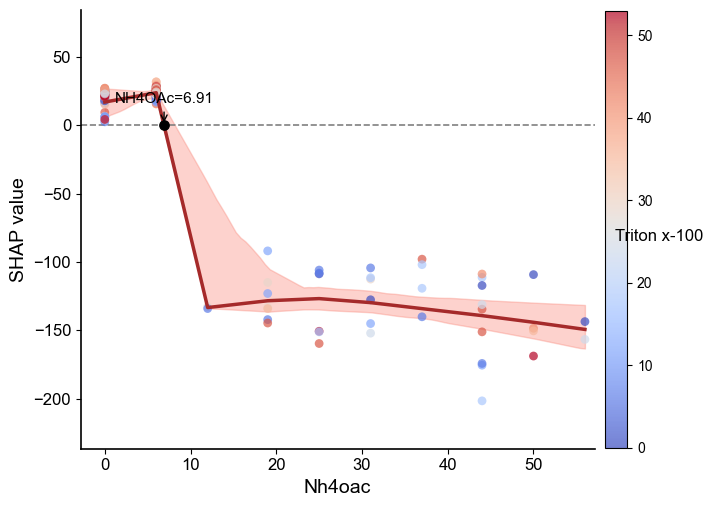

In [25]:
# SHAP 主效应超参数：指定特征精细依赖图。
SHAP_FEATURE_TO_PLOT = "NH4OAc"
SHAP_COLOR_FEATURE = "Triton X-100"
SHAP_DETAIL_LOWESS_FRAC = 0.40
SHAP_BOOTSTRAP_SAMPLES = 100
SHAP_CI_LEVEL = 0.95
SHAP_CI_LOWER_PERCENTILE = (1 - SHAP_CI_LEVEL) * 50
SHAP_CI_UPPER_PERCENTILE = 100 - SHAP_CI_LOWER_PERCENTILE

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from numpy.polynomial.polynomial import Polynomial
from matplotlib.colors import LinearSegmentedColormap  # 导入自定义颜色映射所需的库
import matplotlib.cm as cm  # 导入cm模块

# 选择的特征
feature_to_plot = SHAP_FEATURE_TO_PLOT#我们给 'age' 这个名字贴上了这个标签
# 这里可以替换为其他特征名，如 'cholesterol', 'blood_pressure' 等
feature_to_color = SHAP_COLOR_FEATURE

# 提取数据
X_data_orig = X[feature_to_plot].values#从一个名为 `X_test` 的数据集中，把所有 ‘age’ 这一列始数取出来

Y_data_orig = shap_values_df[feature_to_plot].values#从一个名为 `shap_values_df` 的数据集中，也把 ‘age’ 这一列的数值提取出来
color_data_orig = X[feature_to_color].values


# 过滤NaN/Inf
valid_indices_orig = np.isfinite(X_data_orig) & np.isfinite(Y_data_orig) & np.isfinite(color_data_orig)
#np.isfinite() 会检查每个数据点是不是一个正常的、有限的数字
# 所以这行代码的意思是：“__只有当一个数据点的年龄值和它的SHAP值都是正常数字时，我们才认为它是有效
X_data = X_data_orig[valid_indices_orig]
Y_data = Y_data_orig[valid_indices_orig]
color_data = color_data_orig[valid_indices_orig]

if len(X_data) < 2:
    print(f"特征 '{feature_to_plot}' 的有效数据点不足以绘图。")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.text(0.5, 0.5, f"数据不足: {feature_to_plot}", ha='center', va='center')
    plt.show()
    import sys
    sys.exit()

# LOWESS 拟合 
lowess_frac = SHAP_DETAIL_LOWESS_FRAC
# frac参数控制LOWESS平滑的程度，0.4表示使用40%的数据点进行局部加权回归
# 值越小，曲线就越“贴近”每一个数据点，可能会显得很曲折
# 值越大，曲线就越平滑，可能会忽略一些局部变化
# 0.4意味着算法在计算曲线上某一点时，会参考它周围 40% 的数据点
# 这是一个经验性的选择，用来平衡曲线的平滑度和对数据的拟合度

sort_idx_main = np.argsort(X_data) # 把“年龄”从小到大排队，返回一张“排队顺序表”（索引表）
X_sorted_main = X_data[sort_idx_main]
Y_sorted_main = Y_data[sort_idx_main]# 按刚才的顺序表，把“年龄”和对应的 SHAP 值重新排好队，方便后面画线时不乱

r_squared_lowess = np.nan
# 先给“LOWESS 曲线的拟合优度”留个空盒子，后面算出来再填
# R²（拟合优度）就是 评分卡：
# 0 分表示曲线跟瞎猜没区别，1 分表示曲线完美穿过所有豆子
# 0.5 分表示曲线大致跟豆子走向一致，但有
# 一些豆子偏离曲线
# 这个分数写在论文里，别人一看就知道模型解释力好不好
lowess_interpolation_function = None
# 先给“LOWESS 插值函数”留个空盒子，后面算出来再填
# 插值函数更像 一把“刻度尺”
# 你把任意年龄输进去，它立刻告诉你对应曲线上的 y 值
main_lowess_fit_points = None
# 先给“LOWESS 拟合点”留个空盒子，后面算出来再填
# LOWESS 先在这些豆子之间 插一条光滑的曲线
# 这条曲线由很多“点”组成——每隔一小段 x 就取一个 y，这些 (x, y) 就叫 拟合点

# LOWESS拟合
main_lowess_fit_points = lowess(Y_sorted_main, X_sorted_main, frac=lowess_frac, it=0)
# 阶段1：初始拟合（it=0时只执行此阶段）
# 对每个数据点x_i，确定其邻域内的点
# 基于距离计算权重：距离x_i越近的点权重越高
# 用加权最小二乘法拟合局部多项式回归
# 当it=3（默认值）时，算法会执行以下迭代
# 第一次迭代：

# 计算残差 = 实际值 - 拟合值
# 识别异常值（残差特别大的点）
# 降低异常值的权重（使用bisquare权重函数）
# 重新拟合，减少异常值影响
# 后续迭代：

# 重复上述过程3次
# 每次迭代都进一步降低异常值权重
# 最终得到对异常值不敏感的平滑曲线
plot_main_lowess = True

# 生成唯一的X值对应的Y值
unique_x_lowess, unique_indices = np.unique(main_lowess_fit_points[:, 0], return_index=True)
# 这行代码的作用是：从LOWESS拟合的结果中提取唯一的X值，并返回这些唯一值在原数组中的索引
# main_lowess_fit_points[:, 0]指的是LOWESS拟合结果中的X值列
# 这是因为main_lowess_fit_points是一个二维数组，其中第一列是X值，第二列是对应的Y值
# unique_x_lowess将包含所有唯一的X值，而unique_indices将包含这些唯一X值在原数组中的索引
# 这样做的目的是为了后续处理时只保留每个唯一X值对应的第一个Y值
# 这可以帮助我们在绘图时避免重复的X值，从而使曲线更加清晰
y_for_unique_x_lowess = main_lowess_fit_points[unique_indices, 1]
# 这行代码的作用是：从LOWESS拟合结果中提取唯一X值对应的Y值
# unique_indices是之前得到的唯一X值在原数组中的索引
# main_lowess_fit_points中索引0列是X值，索引1列是Y值
# 通过unique_indices，我们可以获取每个唯一X值对应的第一个Y值
if len(unique_x_lowess) > 1:
    lowess_interpolation_function = interp1d(unique_x_lowess, y_for_unique_x_lowess,
                                             kind='linear', fill_value="extrapolate")
# 这行代码的作用是：创建一个线性插值函数
# interp1d是SciPy库中的一个函数，用于创建一维插值函数
# unique_x_lowess是唯一的X值，y_for_unique_x_lowess是对应的Y值
# kind='linear'表示使用线性插值方法
# fill_value="extrapolate"表示如果查询的X值超出范围，则使用外推法来计算Y值
# 这样，我们就可以使用lowess_interpolation_function来查询任意X值对应的Y值
# extrapolate会让工具查看最后一段已知的趋势（比如从12点到3点的温度变化趋势），给出一个猜测值

x_at_zero = None
y_near_zero = None
if main_lowess_fit_points is not None and len(main_lowess_fit_points) > 1:
    x_fit = main_lowess_fit_points[:, 0]
    y_fit = main_lowess_fit_points[:, 1]
    for i in range(len(y_fit) - 1):
        y1 = y_fit[i]
        y2 = y_fit[i + 1]
        if y1 == 0:
            x_at_zero = x_fit[i]
            y_near_zero = 0.0
            break
        if y1 * y2 < 0 or y2 == 0:
            x1 = x_fit[i]
            x2 = x_fit[i + 1]
            x_at_zero = x1 + (x2 - x1) * (-y1) / (y2 - y1)
            y_near_zero = 0.0
            break
    if x_at_zero is None:
        idx_min = int(np.argmin(np.abs(y_fit)))
        x_at_zero = float(x_fit[idx_min])
        y_near_zero = float(y_fit[idx_min])

# 计算R²值
if lowess_interpolation_function:
    y_pred_for_r2 = lowess_interpolation_function(X_sorted_main)
# 这行代码的作用是：使用之前创建的插值函数lowess_interpolation_function来计算X_sorted_main中每个X值对应的Y值
# 这样，我们就得到了一个预测的Y值数组y_pred_for_r2
# 如果lowess_interpolation_function不存在（可能是因为数据点太少），则使用线性插值
# 否则会报错，所以我们需要检查lowess_interpolation_function是否存在
else:
    temp_interp = interp1d(main_lowess_fit_points[:, 0], main_lowess_fit_points[:, 1], fill_value="extrapolate", kind='linear')
    y_pred_for_r2 = temp_interp(X_sorted_main)
# 这行代码的作用是：使用线性插值函数temp_interp来计算X_sorted_main中每个X值对应的Y值
# fill_value="extrapolate"表示如果查询的X值超出范围，则使用外推法来计算Y值
# kind='linear'表示使用线性插值方法

y_true_for_r2 = Y_sorted_main
ss_res = np.sum((y_true_for_r2 - y_pred_for_r2)**2)
ss_tot = np.sum((y_true_for_r2 - np.mean(y_true_for_r2))**2)
# 计算R²值
# ss_res是残差平方和，表示预测值与实际值之间的差异
# ss_tot是总平方和，表示实际值与其均值之间的差异
# R²值的计算公式为：1 - (ss_res / ss_tot)
if ss_tot < np.finfo(float).eps:# 检查总平方和是否接近于0
    # 如果总平方和接近于0，说明数据点几乎没有变化
    r_squared_lowess = 1.0 if ss_res < np.finfo(float).eps else 0.0
# 如果总平方和接近于0，说明数据点几乎没有变化
# 在这种情况下，我们可以认为LOWESS拟合完美（R²=1）
# 如果残差平方和也接近于0，说明预测值与实际值几乎完全一致
# 否则，R²值为0，表示LOWESS拟合没有解释数据
else:
    r_squared_lowess = 1.0 - (ss_res / ss_tot)


# LOWESS拟合的置信区间 (Bootstrapping) 
n_bootstraps = SHAP_BOOTSTRAP_SAMPLES  # 设置Bootstrap采样次数
# Bootstrap是一种重采样技术，通过对原始数据集进行有放回的随机抽样，生成多个"伪数据集"（Bootstrap样本），用于：
# 估计统计量的分布
# 计算置信区间
# 评估模型稳定性
# 设置随机种子以保证可复现性
random_seed = RANDOM_SEED  # 设置随机种子以保证可复现性
np.random.seed(random_seed)  # 固定随机种子
# 这行代码的作用是：设置NumPy的随机种子为42
# 这样做的目的是为了确保每次运行代码时生成的随机数序列都是相同的
# 这对于调试和结果复现非常重要，因为随机数生成器在每次运行时都会生成不同的随机数
# 通过设置随机种子，我们可以确保每次运行代码时，Bootstrap采样和其他随机操作的结果都是一致的

# 设置置信区间的范围
x_min_plot_ci, x_max_plot_ci = (X_data.min(), X_data.max()) if len(X_data) > 0 else (0, 1)
# 计算置信区间的X值范围
# 这行代码的作用是：计算X_data的最小值和最大值
# 如果X_data中有数据点，则使用其最小值和最大值
# 否则，默认范围为0到1
x_smooth_for_ci = np.linspace(x_min_plot_ci, x_max_plot_ci, 100)
# 生成平滑的X值，用于绘制置信区间
# 这行代码的作用是：生成一个从x_min_plot_ci到x_max_plot_ci的平滑X值序列
# linspace函数会在这个范围内生成100个等间距的点

boot_lowess_preds = []  # 存储每次Bootstrap采样的LOWESS预测
# 初始化一个空列表，用于存储每次Bootstrap采样的LOWESS预测结果
# 这个列表会在后续的Bootstrap循环中被填充
plot_ci = False  # 初始化置信区间绘制标记
# 初始化置信区间绘制标记为False
# 这个标记用于控制是否绘制LOWESS的置信区间

# 如果数据点大于1并且启用了LOWESS绘制
if len(X_data) > 1 and plot_main_lowess:# 如果数据点大于1并且启用了LOWESS绘制
    for i in range(n_bootstraps):
        # 进行有放回的随机采样
        indices = np.random.choice(len(X_data), len(X_data), replace=True)
        # 这行代码的作用是：从0到len(X_data)-1之间随机选择len(X_data)个索引
        # replace=True表示允许重复选择同一个索引
        # 这样可以模拟Bootstrap采样，即从原始数据中有放回地抽取样本
        # 这会生成一个长度为len(X_data)的索引数组indices
        X_boot, Y_boot = X_data[indices], Y_data[indices]
        # 根据随机索引从原始数据中抽取Bootstrap样本
        # 这行代码的作用是：使用随机索引indices从X_data和Y_data中抽取样本
        # X_boot将包含Bootstrap采样后的特征值，Y_boot将包含对应的SHAP值

        # 排序数据
        sort_idx_boot = np.argsort(X_boot)
        X_boot_sorted, Y_boot_sorted = X_boot[sort_idx_boot], Y_boot[sort_idx_boot]
        # 这行代码的作用是：对X_boot进行排序，并返回排序后的索引
        # np.argsort(X_boot)会返回一个索引数组，表示X_boot中元素从小到大的顺序
        # 这样可以确保在后续的LOWESS拟合中，X值是有序的
        # 这对于LOWESS拟合是必要的，因为它需要在有序的X值上进行局部加权回归
        # 这行代码的作用是：根据排序后的索引对X_boot和Y_boot进行排序
        # 这样可以确保X_boot和Y_boot中的数据点是对应的，并且X_boot_sorted和Y_boot_sorted是有序的
    

        if len(X_boot_sorted) < 2:  # 如果数据不足2个点则跳过
            continue
        
        try:
            # 对Bootstrap采样数据进行LOWESS拟合
            current_boot_lowess = lowess(Y_boot_sorted, X_boot_sorted, frac=lowess_frac, it=0)
            # 这行代码的作用是：对Bootstrap采样数据进行LOWESS拟合
            # lowess函数会返回一个二维数组，其中第一列是X值，第二列是对应的Y值
            
            # 获取唯一的X值和对应的Y值
            unique_x_boot, unique_idx_boot = np.unique(current_boot_lowess[:, 0], return_index=True)
            y_for_unique_x_boot = current_boot_lowess[unique_idx_boot, 1]
            
            if len(unique_x_boot) > 1:
                # 线性插值
                y_interp_boot = np.interp(x_smooth_for_ci, unique_x_boot, y_for_unique_x_boot)
                # 这行代码的作用是：使用线性插值方法将y_for_unique_x_boot中的Y值映射到x_smooth_for_ci对应的X值上
                # interp函数会根据unique_x_boot和y_for_unique_x_boot创建一个插值函数
                # 然后使用这个插值函数计算x_smooth_for_ci中每个X值对应的Y值
                # 这样可以得到一个平滑的Y值序列y_interp_boot，用于绘制置信区间
                boot_lowess_preds.append(y_interp_boot)
        except Exception: 
            continue

    # 如果有有效的Bootstrap预测，则计算置信区间
    if boot_lowess_preds:
        boot_lowess_preds_array = np.array(boot_lowess_preds)
        # 将Bootstrap预测列表转换为NumPy数组
        # 这行代码的作用是：将boot_lowess_preds列表转换为一个NumPy数组
        # 这样可以方便地进行后续的统计计算和绘图操作
        ci_lower = np.percentile(boot_lowess_preds_array, SHAP_CI_LOWER_PERCENTILE, axis=0)  # 计算2.5%分位数
        ci_upper = np.percentile(boot_lowess_preds_array, SHAP_CI_UPPER_PERCENTILE, axis=0)  # 计算97.5%分位数
        plot_ci = True  # 启用置信区间绘制

#  绘图 
fig, ax = plt.subplots(figsize=(8, 5.5))  # 稍微调整图形大小以便容纳颜色条
# 这行代码的作用是：创建一个新的图形和坐标轴对象
# figsize=(8, 5.5)指定图形的宽度和高度，

# 定义颜色映射 
# colors_for_cmap = ['#ADD8E6', '#D8BFD8', '#DA70D6', '#FF00FF']  # 浅蓝, 蓟色, 紫兰花色, 洋红
# custom_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", colors_for_cmap)
custom_cmap=plt.cm.coolwarm
# 这行代码的作用是：创建一个自定义的线性分段颜色映射
# LinearSegmentedColormap.from_list()函数接受两个参数：

# 绘制散点图，颜色根据 X_data (特征值) 进行映射
scatter_plot = ax.scatter(X_data, Y_data, s=40, c=color_data, cmap=custom_cmap, alpha=0.7, edgecolor='none', zorder=2)
# 这行代码的作用是：在坐标轴上绘制一个散点图
# X_data是散点图的X坐标，Y_data是散点图的Y坐标
# s=40表示每个点的大小为40
# c=X_data表示点的颜色根据X_data的值进行映射
# cmap=custom_cmap表示使用自定义的颜色映射

# 绘制LOWESS趋势线
if plot_main_lowess and main_lowess_fit_points is not None:
    ax.plot(main_lowess_fit_points[:, 0], main_lowess_fit_points[:, 1], color='#A52A2A', linewidth=2.5, label='Trendline (LOWESS)', zorder=3)
# 这行代码的作用是：在坐标轴上绘制LOWESS拟合的趋势线
# main_lowess_fit_points[:, 0]是X值，main_lowess_fit_points[:, 1]是对应的Y值
# color='#A52A2A'指定趋势线的颜色为棕色
# 绘制LOWESS的95%置信区间
if plot_ci:
    ax.fill_between(x_smooth_for_ci, ci_lower, ci_upper, color='salmon', alpha=0.35, label='95% CI (LOWESS)', zorder=1)
# 这行代码的作用是：在坐标轴上绘制LOWESS的95%置信区间
# x_smooth_for_ci这是我们为ci_lower和ci_upper提供X轴坐标的列表，要让代码知道这置信区间画在哪里
# x_smooth_for_ci是平滑的X值序列，ci_lower和ci_upper分别是置信区间的下限和上限
# color='salmon'指定置信区间的填充颜色为浅红色

ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, zorder=1)

# 设置标签和刻度
ax.set_xlabel(feature_to_plot.capitalize(), fontsize=14)
# 这行代码的作用是：设置X轴标签为特征名称（首字母大写）
# feature_to_plot.capitalize()会将特征名称的首字母大写
ax.set_ylabel("SHAP value", fontsize=14)
# 这行代码的作用是：设置Y轴标签为"SHAP value"
ax.tick_params(axis='both', which='major', labelsize=12)
# 这行代码的作用是：设置坐标轴刻度的字体大小为12

# 坐标轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)



# 坐标轴范围
if len(X_data) > 0:
    ax.set_xlim(left=X_data.min() - (X_data.max()-X_data.min()) * 0.05, right=X_data.max() * 1.02)
    all_y_for_lim = [Y_data]
    if plot_ci: all_y_for_lim.extend([ci_lower, ci_upper])
    if plot_main_lowess and main_lowess_fit_points is not None: all_y_for_lim.append(main_lowess_fit_points[:, 1])
    concatenated_y_values = np.concatenate([arr[np.isfinite(arr)] for arr in all_y_for_lim if len(arr[np.isfinite(arr)]) > 0])
    if len(concatenated_y_values) > 0:
        y_min_plot, y_max_plot = np.nanmin(concatenated_y_values), np.nanmax(concatenated_y_values)
        padding_y = (y_max_plot - y_min_plot) * 0.15
        ax.set_ylim(bottom=y_min_plot - padding_y, top=y_max_plot + padding_y * 1.5)
    else:
        ax.set_ylim(-1, 1)
else:
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)

if 'x_at_zero' in locals() and x_at_zero is not None and y_near_zero is not None:
    ax.scatter([x_at_zero], [y_near_zero if np.isfinite(y_near_zero) else 0], color='black', s=45, zorder=4)
    ax.annotate(f'{feature_to_plot}={x_at_zero:.2f}', xy=(x_at_zero, y_near_zero if np.isfinite(y_near_zero) else 0), xytext=(x_at_zero, (y_near_zero if np.isfinite(y_near_zero) else 0) + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0])),
                textcoords='data', ha='center', fontsize=11, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

# --- 添加颜色映射条 ---
cbar = fig.colorbar(scatter_plot, ax=ax, orientation='vertical', fraction=0.040, pad=0.02)
# 这行代码的作用是：在图形中添加一个颜色条（colorbar）
# scatter_plot是之前绘制的散点图对象，ax是坐标轴对象
cbar.set_label(feature_to_color.capitalize(), rotation=0, labelpad=5, fontsize=12)


# 调整布局以适应颜色条和可能的标题
plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])  # 调整 rect 的第三个参数为颜色条腾出空间

            
plt.savefig(SHAP_MAIN_OUTPUT_DIR / f"{safe_filename(feature_to_plot)}.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.show()

### 3.8 可复用的 SHAP 特征绘图函数

将单特征 SHAP 依赖图的清洗、平滑、阈值识别、着色和保存流程封装为 `plot_shap_feature`，并按当前着色特征批量绘制全部特征。

d:\apps\Anaconda\envs\learn\lib\site-packages\statsmodels\nonparametric\smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


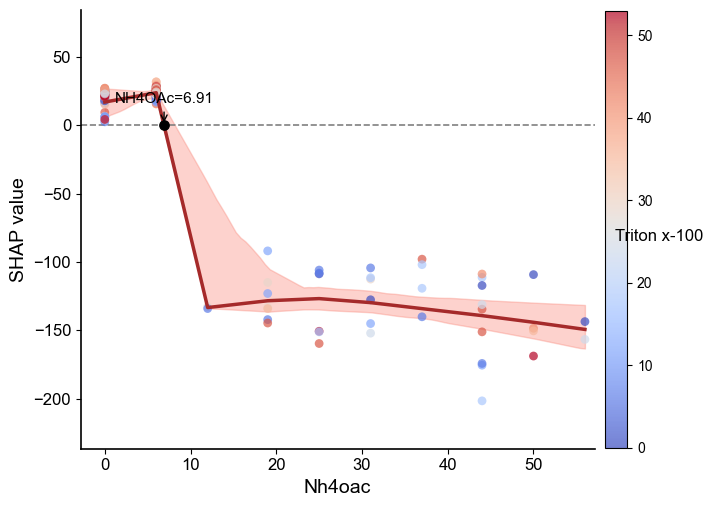


KeyboardInterrupt



In [26]:
# SHAP 主效应超参数：批量依赖图的着色变量与平滑、置信区间设置。
SHAP_BATCH_COLOR_FEATURE = "Triton X-100"
SHAP_DETAIL_LOWESS_FRAC = 0.40
SHAP_BOOTSTRAP_SAMPLES = 100
SHAP_CI_LEVEL = 0.95
SHAP_CI_LOWER_PERCENTILE = (1 - SHAP_CI_LEVEL) * 50
SHAP_CI_UPPER_PERCENTILE = 100 - SHAP_CI_LOWER_PERCENTILE

from statsmodels.nonparametric.smoothers_lowess import lowess
from scipy.interpolate import interp1d
from numpy.polynomial.polynomial import Polynomial
from matplotlib.colors import LinearSegmentedColormap  # 导入自定义颜色映射所需的库
import matplotlib.cm as cm  # 导入cm模块

def plot_shap_feature(feature_to_plot, feature_to_color):
    X_data_orig = X[feature_to_plot].values
    Y_data_orig = shap_values_df[feature_to_plot].values
    color_data_orig = X[feature_to_color].values
    valid = np.isfinite(X_data_orig) & np.isfinite(Y_data_orig) & np.isfinite(color_data_orig)
    X_data = X_data_orig[valid]
    Y_data = Y_data_orig[valid]
    color_data = color_data_orig[valid]
    fig, ax = plt.subplots(figsize=(8, 5.5))
    if len(X_data) < 2:
        ax.text(0.5, 0.5, f"数据不足: {feature_to_plot}", ha='center', va='center')
        plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])
        plt.savefig(SHAP_MAIN_OUTPUT_DIR / f"{safe_filename(feature_to_plot)}.pdf", format='pdf', bbox_inches='tight', dpi=1200)
        plt.show()
        plt.close(fig)
        return
    lowess_frac = SHAP_DETAIL_LOWESS_FRAC
    idx = np.argsort(X_data)
    X_sorted = X_data[idx]
    Y_sorted = Y_data[idx]
    fit = lowess(Y_sorted, X_sorted, frac=lowess_frac, it=0)
    xfit = fit[:, 0]
    yfit = fit[:, 1]

    n_bootstraps = SHAP_BOOTSTRAP_SAMPLES
    random_seed = RANDOM_SEED
    np.random.seed(random_seed)
    x_min_plot_ci, x_max_plot_ci = (X_data.min(), X_data.max()) if len(X_data) > 0 else (0, 1)
    x_smooth_for_ci = np.linspace(x_min_plot_ci, x_max_plot_ci, 100)
    boot_lowess_preds = []
    if len(X_data) > 1:
        for _ in range(n_bootstraps):
            indices = np.random.choice(len(X_data), len(X_data), replace=True)
            X_boot, Y_boot = X_data[indices], Y_data[indices]
            sort_idx_boot = np.argsort(X_boot)
            X_boot_sorted, Y_boot_sorted = X_boot[sort_idx_boot], Y_boot[sort_idx_boot]
            if len(X_boot_sorted) < 2:
                continue
            try:
                current_boot_lowess = lowess(Y_boot_sorted, X_boot_sorted, frac=lowess_frac, it=0)
                unique_x_boot, unique_idx_boot = np.unique(current_boot_lowess[:, 0], return_index=True)
                y_for_unique_x_boot = current_boot_lowess[unique_idx_boot, 1]
                if len(unique_x_boot) > 1:
                    y_interp_boot = np.interp(x_smooth_for_ci, unique_x_boot, y_for_unique_x_boot)
                    boot_lowess_preds.append(y_interp_boot)
            except Exception:
                continue
    plot_ci = False
    if boot_lowess_preds:
        boot_lowess_preds_array = np.array(boot_lowess_preds)
        ci_lower = np.percentile(boot_lowess_preds_array, SHAP_CI_LOWER_PERCENTILE, axis=0)
        ci_upper = np.percentile(boot_lowess_preds_array, SHAP_CI_UPPER_PERCENTILE, axis=0)
        plot_ci = True
    x_at_zero = None
    y_near_zero = None
    for i in range(len(yfit) - 1):
        y1 = yfit[i]
        y2 = yfit[i + 1]
        if y1 == 0:
            x_at_zero = xfit[i]
            y_near_zero = 0.0
            break
        if y1 * y2 < 0 or y2 == 0:
            x1 = xfit[i]
            x2 = xfit[i + 1]
            x_at_zero = x1 + (x2 - x1) * (-y1) / (y2 - y1)
            y_near_zero = 0.0
            break
    if x_at_zero is None and len(yfit) > 0:
        j = int(np.argmin(np.abs(yfit)))
        x_at_zero = float(xfit[j])
        y_near_zero = float(yfit[j])
    custom_cmap = plt.cm.coolwarm
    sc = ax.scatter(X_data, Y_data, s=40, c=color_data, cmap=custom_cmap, alpha=0.7, edgecolor='none', zorder=2)
    ax.plot(xfit, yfit, color='#A52A2A', linewidth=2.5, label='Trendline (LOWESS)', zorder=3)
    if plot_ci:
        ax.fill_between(x_smooth_for_ci, ci_lower, ci_upper, color='salmon', alpha=0.35, label='95% CI (LOWESS)', zorder=1)
    ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, zorder=1)
    ax.set_xlabel(feature_to_plot.capitalize(), fontsize=14)
    ax.set_ylabel("SHAP value", fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=12)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_linewidth(1.2)
    ax.spines['bottom'].set_linewidth(1.2)
    if len(X_data) > 0:
        ax.set_xlim(left=X_data.min() - (X_data.max() - X_data.min()) * 0.05, right=X_data.max() * 1.02)
        fy = np.concatenate([Y_data[np.isfinite(Y_data)], yfit[np.isfinite(yfit)], (ci_lower if 'plot_ci' in locals() and plot_ci else np.array([])), (ci_upper if 'plot_ci' in locals() and plot_ci else np.array([]))]) if (np.isfinite(Y_data).any() or np.isfinite(yfit).any()) else np.array([])
        if fy.size > 0:
            ymin = np.nanmin(fy)
            ymax = np.nanmax(fy)
            pad = (ymax - ymin) * 0.15
            ax.set_ylim(ymin - pad, ymax + pad * 1.5)
        else:
            ax.set_ylim(-1, 1)
    else:
        ax.set_xlim(0, 1)
        ax.set_ylim(-1, 1)
    if x_at_zero is not None and y_near_zero is not None:
        y_mark = y_near_zero if np.isfinite(y_near_zero) else 0
        ax.scatter([x_at_zero], [y_mark], color='black', s=45, zorder=4)
        ax.annotate(f'{feature_to_plot}={x_at_zero:.2f}', xy=(x_at_zero, y_mark),
                    xytext=(x_at_zero, y_mark + 0.05 * (ax.get_ylim()[1] - ax.get_ylim()[0])),
                    textcoords='data', ha='center', fontsize=11, color='black',
                    arrowprops=dict(arrowstyle='->', color='black', lw=1))
    cbar = fig.colorbar(sc, ax=ax, orientation='vertical', fraction=0.040, pad=0.02)
    cbar.set_label(feature_to_color.capitalize(), rotation=0, labelpad=5, fontsize=12)
    cbar.outline.set_visible(False)
    plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])
    plt.savefig(SHAP_MAIN_OUTPUT_DIR / f"{safe_filename(feature_to_plot)}.pdf", format='pdf', bbox_inches='tight', dpi=1200)
    plt.show()
    plt.close(fig)

# 选择的特征
feature_to_plot = SHAP_FEATURE_TO_PLOT#我们给 'age' 这个名字贴上了这个标签
# 这里可以替换为其他特征名，如 'cholesterol', 'blood_pressure' 等
feature_to_color = SHAP_COLOR_FEATURE

# 提取数据
X_data_orig = X[feature_to_plot].values#从一个名为 `X_test` 的数据集中，把所有 ‘age’ 这一列始数取出来

Y_data_orig = shap_values_df[feature_to_plot].values#从一个名为 `shap_values_df` 的数据集中，也把 ‘age’ 这一列的数值提取出来
color_data_orig = X[feature_to_color].values


# 过滤NaN/Inf
valid_indices_orig = np.isfinite(X_data_orig) & np.isfinite(Y_data_orig) & np.isfinite(color_data_orig)
#np.isfinite() 会检查每个数据点是不是一个正常的、有限的数字
# 所以这行代码的意思是：“__只有当一个数据点的年龄值和它的SHAP值都是正常数字时，我们才认为它是有效
X_data = X_data_orig[valid_indices_orig]
Y_data = Y_data_orig[valid_indices_orig]
color_data = color_data_orig[valid_indices_orig]

if len(X_data) < 2:
    print(f"特征 '{feature_to_plot}' 的有效数据点不足以绘图。")
    fig, ax = plt.subplots(figsize=(7, 5.5))
    ax.text(0.5, 0.5, f"数据不足: {feature_to_plot}", ha='center', va='center')
    plt.show()
    import sys
    sys.exit()

# LOWESS 拟合 
lowess_frac = SHAP_DETAIL_LOWESS_FRAC
# frac参数控制LOWESS平滑的程度，0.4表示使用40%的数据点进行局部加权回归
# 值越小，曲线就越“贴近”每一个数据点，可能会显得很曲折
# 值越大，曲线就越平滑，可能会忽略一些局部变化
# 0.4意味着算法在计算曲线上某一点时，会参考它周围 40% 的数据点
# 这是一个经验性的选择，用来平衡曲线的平滑度和对数据的拟合度

sort_idx_main = np.argsort(X_data) # 把“年龄”从小到大排队，返回一张“排队顺序表”（索引表）
X_sorted_main = X_data[sort_idx_main]
Y_sorted_main = Y_data[sort_idx_main]# 按刚才的顺序表，把“年龄”和对应的 SHAP 值重新排好队，方便后面画线时不乱

r_squared_lowess = np.nan
# 先给“LOWESS 曲线的拟合优度”留个空盒子，后面算出来再填
# R²（拟合优度）就是 评分卡：
# 0 分表示曲线跟瞎猜没区别，1 分表示曲线完美穿过所有豆子
# 0.5 分表示曲线大致跟豆子走向一致，但有
# 一些豆子偏离曲线
# 这个分数写在论文里，别人一看就知道模型解释力好不好
lowess_interpolation_function = None
# 先给“LOWESS 插值函数”留个空盒子，后面算出来再填
# 插值函数更像 一把“刻度尺”
# 你把任意年龄输进去，它立刻告诉你对应曲线上的 y 值
main_lowess_fit_points = None
# 先给“LOWESS 拟合点”留个空盒子，后面算出来再填
# LOWESS 先在这些豆子之间 插一条光滑的曲线
# 这条曲线由很多“点”组成——每隔一小段 x 就取一个 y，这些 (x, y) 就叫 拟合点

# LOWESS拟合
main_lowess_fit_points = lowess(Y_sorted_main, X_sorted_main, frac=lowess_frac, it=0)
# 阶段1：初始拟合（it=0时只执行此阶段）
# 对每个数据点x_i，确定其邻域内的点
# 基于距离计算权重：距离x_i越近的点权重越高
# 用加权最小二乘法拟合局部多项式回归
# 当it=3（默认值）时，算法会执行以下迭代
# 第一次迭代：

# 计算残差 = 实际值 - 拟合值
# 识别异常值（残差特别大的点）
# 降低异常值的权重（使用bisquare权重函数）
# 重新拟合，减少异常值影响
# 后续迭代：

# 重复上述过程3次
# 每次迭代都进一步降低异常值权重
# 最终得到对异常值不敏感的平滑曲线
plot_main_lowess = True

# 生成唯一的X值对应的Y值
unique_x_lowess, unique_indices = np.unique(main_lowess_fit_points[:, 0], return_index=True)
# 这行代码的作用是：从LOWESS拟合的结果中提取唯一的X值，并返回这些唯一值在原数组中的索引
# main_lowess_fit_points[:, 0]指的是LOWESS拟合结果中的X值列
# 这是因为main_lowess_fit_points是一个二维数组，其中第一列是X值，第二列是对应的Y值
# unique_x_lowess将包含所有唯一的X值，而unique_indices将包含这些唯一X值在原数组中的索引
# 这样做的目的是为了后续处理时只保留每个唯一X值对应的第一个Y值
# 这可以帮助我们在绘图时避免重复的X值，从而使曲线更加清晰
y_for_unique_x_lowess = main_lowess_fit_points[unique_indices, 1]
# 这行代码的作用是：从LOWESS拟合结果中提取唯一X值对应的Y值
# unique_indices是之前得到的唯一X值在原数组中的索引
# main_lowess_fit_points中索引0列是X值，索引1列是Y值
# 通过unique_indices，我们可以获取每个唯一X值对应的第一个Y值
if len(unique_x_lowess) > 1:
    lowess_interpolation_function = interp1d(unique_x_lowess, y_for_unique_x_lowess,
                                             kind='linear', fill_value="extrapolate")
# 这行代码的作用是：创建一个线性插值函数
# interp1d是SciPy库中的一个函数，用于创建一维插值函数
# unique_x_lowess是唯一的X值，y_for_unique_x_lowess是对应的Y值
# kind='linear'表示使用线性插值方法
# fill_value="extrapolate"表示如果查询的X值超出范围，则使用外推法来计算Y值
# 这样，我们就可以使用lowess_interpolation_function来查询任意X值对应的Y值
# extrapolate会让工具查看最后一段已知的趋势（比如从12点到3点的温度变化趋势），给出一个猜测值

x_at_zero = None
y_near_zero = None
if main_lowess_fit_points is not None and len(main_lowess_fit_points) > 1:
    x_fit = main_lowess_fit_points[:, 0]
    y_fit = main_lowess_fit_points[:, 1]
    for i in range(len(y_fit) - 1):
        y1 = y_fit[i]
        y2 = y_fit[i + 1]
        if y1 == 0:
            x_at_zero = x_fit[i]
            y_near_zero = 0.0
            break
        if y1 * y2 < 0 or y2 == 0:
            x1 = x_fit[i]
            x2 = x_fit[i + 1]
            x_at_zero = x1 + (x2 - x1) * (-y1) / (y2 - y1)
            y_near_zero = 0.0
            break
    if x_at_zero is None:
        idx_min = int(np.argmin(np.abs(y_fit)))
        x_at_zero = float(x_fit[idx_min])
        y_near_zero = float(y_fit[idx_min])

# 计算R²值
if lowess_interpolation_function:
    y_pred_for_r2 = lowess_interpolation_function(X_sorted_main)
# 这行代码的作用是：使用之前创建的插值函数lowess_interpolation_function来计算X_sorted_main中每个X值对应的Y值
# 这样，我们就得到了一个预测的Y值数组y_pred_for_r2
# 如果lowess_interpolation_function不存在（可能是因为数据点太少），则使用线性插值
# 否则会报错，所以我们需要检查lowess_interpolation_function是否存在
else:
    temp_interp = interp1d(main_lowess_fit_points[:, 0], main_lowess_fit_points[:, 1], fill_value="extrapolate", kind='linear')
    y_pred_for_r2 = temp_interp(X_sorted_main)
# 这行代码的作用是：使用线性插值函数temp_interp来计算X_sorted_main中每个X值对应的Y值
# fill_value="extrapolate"表示如果查询的X值超出范围，则使用外推法来计算Y值
# kind='linear'表示使用线性插值方法

y_true_for_r2 = Y_sorted_main
ss_res = np.sum((y_true_for_r2 - y_pred_for_r2)**2)
ss_tot = np.sum((y_true_for_r2 - np.mean(y_true_for_r2))**2)
# 计算R²值
# ss_res是残差平方和，表示预测值与实际值之间的差异
# ss_tot是总平方和，表示实际值与其均值之间的差异
# R²值的计算公式为：1 - (ss_res / ss_tot)
if ss_tot < np.finfo(float).eps:# 检查总平方和是否接近于0
    # 如果总平方和接近于0，说明数据点几乎没有变化
    r_squared_lowess = 1.0 if ss_res < np.finfo(float).eps else 0.0
# 如果总平方和接近于0，说明数据点几乎没有变化
# 在这种情况下，我们可以认为LOWESS拟合完美（R²=1）
# 如果残差平方和也接近于0，说明预测值与实际值几乎完全一致
# 否则，R²值为0，表示LOWESS拟合没有解释数据
else:
    r_squared_lowess = 1.0 - (ss_res / ss_tot)


# LOWESS拟合的置信区间 (Bootstrapping) 
n_bootstraps = SHAP_BOOTSTRAP_SAMPLES  # 设置Bootstrap采样次数
# Bootstrap是一种重采样技术，通过对原始数据集进行有放回的随机抽样，生成多个"伪数据集"（Bootstrap样本），用于：
# 估计统计量的分布
# 计算置信区间
# 评估模型稳定性
# 设置随机种子以保证可复现性
random_seed = RANDOM_SEED  # 设置随机种子以保证可复现性
np.random.seed(random_seed)  # 固定随机种子
# 这行代码的作用是：设置NumPy的随机种子为42
# 这样做的目的是为了确保每次运行代码时生成的随机数序列都是相同的
# 这对于调试和结果复现非常重要，因为随机数生成器在每次运行时都会生成不同的随机数
# 通过设置随机种子，我们可以确保每次运行代码时，Bootstrap采样和其他随机操作的结果都是一致的

# 设置置信区间的范围
x_min_plot_ci, x_max_plot_ci = (X_data.min(), X_data.max()) if len(X_data) > 0 else (0, 1)
# 计算置信区间的X值范围
# 这行代码的作用是：计算X_data的最小值和最大值
# 如果X_data中有数据点，则使用其最小值和最大值
# 否则，默认范围为0到1
x_smooth_for_ci = np.linspace(x_min_plot_ci, x_max_plot_ci, 100)
# 生成平滑的X值，用于绘制置信区间
# 这行代码的作用是：生成一个从x_min_plot_ci到x_max_plot_ci的平滑X值序列
# linspace函数会在这个范围内生成100个等间距的点

boot_lowess_preds = []  # 存储每次Bootstrap采样的LOWESS预测
# 初始化一个空列表，用于存储每次Bootstrap采样的LOWESS预测结果
# 这个列表会在后续的Bootstrap循环中被填充
plot_ci = False  # 初始化置信区间绘制标记
# 初始化置信区间绘制标记为False
# 这个标记用于控制是否绘制LOWESS的置信区间

# 如果数据点大于1并且启用了LOWESS绘制
if len(X_data) > 1 and plot_main_lowess:# 如果数据点大于1并且启用了LOWESS绘制
    for i in range(n_bootstraps):
        # 进行有放回的随机采样
        indices = np.random.choice(len(X_data), len(X_data), replace=True)
        # 这行代码的作用是：从0到len(X_data)-1之间随机选择len(X_data)个索引
        # replace=True表示允许重复选择同一个索引
        # 这样可以模拟Bootstrap采样，即从原始数据中有放回地抽取样本
        # 这会生成一个长度为len(X_data)的索引数组indices
        X_boot, Y_boot = X_data[indices], Y_data[indices]
        # 根据随机索引从原始数据中抽取Bootstrap样本
        # 这行代码的作用是：使用随机索引indices从X_data和Y_data中抽取样本
        # X_boot将包含Bootstrap采样后的特征值，Y_boot将包含对应的SHAP值

        # 排序数据
        sort_idx_boot = np.argsort(X_boot)
        X_boot_sorted, Y_boot_sorted = X_boot[sort_idx_boot], Y_boot[sort_idx_boot]
        # 这行代码的作用是：对X_boot进行排序，并返回排序后的索引
        # np.argsort(X_boot)会返回一个索引数组，表示X_boot中元素从小到大的顺序
        # 这样可以确保在后续的LOWESS拟合中，X值是有序的
        # 这对于LOWESS拟合是必要的，因为它需要在有序的X值上进行局部加权回归
        # 这行代码的作用是：根据排序后的索引对X_boot和Y_boot进行排序
        # 这样可以确保X_boot和Y_boot中的数据点是对应的，并且X_boot_sorted和Y_boot_sorted是有序的
    

        if len(X_boot_sorted) < 2:  # 如果数据不足2个点则跳过
            continue
        
        try:
            # 对Bootstrap采样数据进行LOWESS拟合
            current_boot_lowess = lowess(Y_boot_sorted, X_boot_sorted, frac=lowess_frac, it=0)
            # 这行代码的作用是：对Bootstrap采样数据进行LOWESS拟合
            # lowess函数会返回一个二维数组，其中第一列是X值，第二列是对应的Y值
            
            # 获取唯一的X值和对应的Y值
            unique_x_boot, unique_idx_boot = np.unique(current_boot_lowess[:, 0], return_index=True)
            y_for_unique_x_boot = current_boot_lowess[unique_idx_boot, 1]
            
            if len(unique_x_boot) > 1:
                # 线性插值
                y_interp_boot = np.interp(x_smooth_for_ci, unique_x_boot, y_for_unique_x_boot)
                # 这行代码的作用是：使用线性插值方法将y_for_unique_x_boot中的Y值映射到x_smooth_for_ci对应的X值上
                # interp函数会根据unique_x_boot和y_for_unique_x_boot创建一个插值函数
                # 然后使用这个插值函数计算x_smooth_for_ci中每个X值对应的Y值
                # 这样可以得到一个平滑的Y值序列y_interp_boot，用于绘制置信区间
                boot_lowess_preds.append(y_interp_boot)
        except Exception: 
            continue

    # 如果有有效的Bootstrap预测，则计算置信区间
    if boot_lowess_preds:
        boot_lowess_preds_array = np.array(boot_lowess_preds)
        # 将Bootstrap预测列表转换为NumPy数组
        # 这行代码的作用是：将boot_lowess_preds列表转换为一个NumPy数组
        # 这样可以方便地进行后续的统计计算和绘图操作
        ci_lower = np.percentile(boot_lowess_preds_array, SHAP_CI_LOWER_PERCENTILE, axis=0)  # 计算2.5%分位数
        ci_upper = np.percentile(boot_lowess_preds_array, SHAP_CI_UPPER_PERCENTILE, axis=0)  # 计算97.5%分位数
        plot_ci = True  # 启用置信区间绘制

#  绘图 
fig, ax = plt.subplots(figsize=(8, 5.5))  # 稍微调整图形大小以便容纳颜色条
# 这行代码的作用是：创建一个新的图形和坐标轴对象
# figsize=(8, 5.5)指定图形的宽度和高度，

# 定义颜色映射 
# colors_for_cmap = ['#ADD8E6', '#D8BFD8', '#DA70D6', '#FF00FF']  # 浅蓝, 蓟色, 紫兰花色, 洋红
# custom_cmap = LinearSegmentedColormap.from_list("my_custom_cmap", colors_for_cmap)
custom_cmap=plt.cm.coolwarm
# 这行代码的作用是：创建一个自定义的线性分段颜色映射
# LinearSegmentedColormap.from_list()函数接受两个参数：

# 绘制散点图，颜色根据 X_data (特征值) 进行映射
scatter_plot = ax.scatter(X_data, Y_data, s=40, c=color_data, cmap=custom_cmap, alpha=0.7, edgecolor='none', zorder=2)
# 这行代码的作用是：在坐标轴上绘制一个散点图
# X_data是散点图的X坐标，Y_data是散点图的Y坐标
# s=40表示每个点的大小为40
# c=X_data表示点的颜色根据X_data的值进行映射
# cmap=custom_cmap表示使用自定义的颜色映射

# 绘制LOWESS趋势线
if plot_main_lowess and main_lowess_fit_points is not None:
    ax.plot(main_lowess_fit_points[:, 0], main_lowess_fit_points[:, 1], color='#A52A2A', linewidth=2.5, label='Trendline (LOWESS)', zorder=3)
# 这行代码的作用是：在坐标轴上绘制LOWESS拟合的趋势线
# main_lowess_fit_points[:, 0]是X值，main_lowess_fit_points[:, 1]是对应的Y值
# color='#A52A2A'指定趋势线的颜色为棕色
# 绘制LOWESS的95%置信区间
if plot_ci:
    ax.fill_between(x_smooth_for_ci, ci_lower, ci_upper, color='salmon', alpha=0.35, label='95% CI (LOWESS)', zorder=1)
# 这行代码的作用是：在坐标轴上绘制LOWESS的95%置信区间
# x_smooth_for_ci这是我们为ci_lower和ci_upper提供X轴坐标的列表，要让代码知道这置信区间画在哪里
# x_smooth_for_ci是平滑的X值序列，ci_lower和ci_upper分别是置信区间的下限和上限
# color='salmon'指定置信区间的填充颜色为浅红色

ax.axhline(0, color='gray', linestyle='--', linewidth=1.2, zorder=1)

# 设置标签和刻度
ax.set_xlabel(feature_to_plot.capitalize(), fontsize=14)
# 这行代码的作用是：设置X轴标签为特征名称（首字母大写）
# feature_to_plot.capitalize()会将特征名称的首字母大写
ax.set_ylabel("SHAP value", fontsize=14)
# 这行代码的作用是：设置Y轴标签为"SHAP value"
ax.tick_params(axis='both', which='major', labelsize=12)
# 这行代码的作用是：设置坐标轴刻度的字体大小为12

# 坐标轴线
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)



# 坐标轴范围
if len(X_data) > 0:
    ax.set_xlim(left=X_data.min() - (X_data.max()-X_data.min()) * 0.05, right=X_data.max() * 1.02)
    all_y_for_lim = [Y_data]
    if plot_ci: all_y_for_lim.extend([ci_lower, ci_upper])
    if plot_main_lowess and main_lowess_fit_points is not None: all_y_for_lim.append(main_lowess_fit_points[:, 1])
    concatenated_y_values = np.concatenate([arr[np.isfinite(arr)] for arr in all_y_for_lim if len(arr[np.isfinite(arr)]) > 0])
    if len(concatenated_y_values) > 0:
        y_min_plot, y_max_plot = np.nanmin(concatenated_y_values), np.nanmax(concatenated_y_values)
        padding_y = (y_max_plot - y_min_plot) * 0.15
        ax.set_ylim(bottom=y_min_plot - padding_y, top=y_max_plot + padding_y * 1.5)
    else:
        ax.set_ylim(-1, 1)
else:
    ax.set_xlim(0, 1)
    ax.set_ylim(-1, 1)

if 'x_at_zero' in locals() and x_at_zero is not None and y_near_zero is not None:
    ax.scatter([x_at_zero], [y_near_zero if np.isfinite(y_near_zero) else 0], color='black', s=45, zorder=4)
    ax.annotate(f'{feature_to_plot}={x_at_zero:.2f}', xy=(x_at_zero, y_near_zero if np.isfinite(y_near_zero) else 0), xytext=(x_at_zero, (y_near_zero if np.isfinite(y_near_zero) else 0) + 0.05*(ax.get_ylim()[1]-ax.get_ylim()[0])),
                textcoords='data', ha='center', fontsize=11, color='black',
                arrowprops=dict(arrowstyle='->', color='black', lw=1))

# --- 添加颜色映射条 ---
cbar = fig.colorbar(scatter_plot, ax=ax, orientation='vertical', fraction=0.040, pad=0.02)
# 这行代码的作用是：在图形中添加一个颜色条（colorbar）
# scatter_plot是之前绘制的散点图对象，ax是坐标轴对象
cbar.set_label(feature_to_color.capitalize(), rotation=0, labelpad=5, fontsize=12)


# 调整布局以适应颜色条和可能的标题
plt.tight_layout(rect=[0, 0.03, 0.9, 0.97])

plt.savefig(SHAP_MAIN_OUTPUT_DIR / f"{safe_filename(feature_to_plot)}.pdf", format='pdf', bbox_inches='tight', dpi=1200)
plt.show()

for feature in columns:
    plot_shap_feature(feature, feature_to_color)

### 3.9 更换着色特征后批量绘图

将交互着色变量切换为 `INDUS`，再次调用封装函数，为所有特征批量生成对应的 SHAP 依赖图。

In [ ]:
# SHAP 主效应超参数：本批量绘图程序块的着色特征。
SHAP_BATCH_COLOR_FEATURE = "Triton X-100"

feature_to_color = SHAP_BATCH_COLOR_FEATURE
for feature in columns:
    plot_shap_feature(feature, feature_to_color)

## 4. SHAP 交互效应分析

### 4.1 计算 SHAP 交互值

利用树模型解释器计算样本层面的 SHAP 交互值张量，为分析任意两个特征之间的联合贡献提供数据。

In [ ]:
shap_interaction_values = explainer.shap_interaction_values(X) 

### 4.2 SHAP 交互汇总图

绘制全部特征交互效应的 SHAP 汇总图，并将结果保存为高分辨率 PNG 文件。

In [ ]:
shap.summary_plot(shap_interaction_values, X, show=False)
plt.tight_layout()
plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / 'shap_interaction_summary.png', dpi=300)
plt.show()

### 4.3 SHAP 交互矩阵

对各特征对的绝对 SHAP 交互值取样本均值，构建并可视化交互强度矩阵，同时使用统一色标便于横向比较。

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize


feature_names = columns

# 计算SHAP交互值的平均绝对值
shap_interaction_mean = np.abs(shap_interaction_values).mean(0)

# 创建图形
fig, ax = plt.subplots(figsize=(12, 10))

# 创建颜色映射（模仿原图的颜色方案）
colors = ['#440154', '#31688e', '#35b779', '#fde725']
cmap = LinearSegmentedColormap.from_list('coolwarm', colors)

# 统一的数值归一化 - 使用整个矩阵的范围（除了对角线）
off_diagonal_mask = ~np.eye(shap_interaction_mean.shape[0], dtype=bool)
off_diagonal_values = shap_interaction_mean[off_diagonal_mask]
vmin = off_diagonal_values.min()
vmax = off_diagonal_values.max()
norm = Normalize(vmin=vmin, vmax=vmax)

n_features = len(feature_names)

# 绘制热图内容
for i in range(n_features):
    for j in range(n_features):
        value = shap_interaction_mean[i, j]
        
        if i < j:  # 上三角（主对角线上方）
            # 显示数值，字体颜色根据统一的归一化值映射
            color_intensity = norm(value)
            text_color = cmap(color_intensity)
            
            ax.text(j, i, f'{value:.3f}', 
                   ha='center', va='center', fontsize=9, 
                   color=text_color, fontweight='bold')
                   
        elif i > j:  # 下三角（主对角线下方）
            # 显示圆点，大小和颜色都根据统一的归一化值映射
            # 计算圆点大小（使用统一的归一化）
            size_factor = norm(value)
            size = size_factor * 1000 + 50  # 调整大小范围
            
            # 绘制圆点（使用统一的vmin, vmax）
            ax.scatter(j, i, s=size, c=value, 
                      cmap=cmap, alpha=0.8, 
                      edgecolors='white', linewidth=1,
                      vmin=vmin, vmax=vmax)
        # 主对角线位置 (i == j) 不绘制任何内容

# 设置坐标轴
ax.set_xlim(-0.5, n_features-0.5)
ax.set_ylim(-0.5, n_features-0.5)

# 设置刻度和标签
ax.set_xticks(range(n_features))
ax.set_xticklabels(feature_names, rotation=45, ha='right', fontsize=10)
ax.set_yticks(range(n_features))
ax.set_yticklabels(feature_names, fontsize=10)

# 添加网格线
ax.set_xticks(np.arange(-0.5, n_features, 1), minor=True)
ax.set_yticks(np.arange(-0.5, n_features, 1), minor=True)
ax.set_title('SHAP Interaction Value Matrix', fontsize=14, fontweight='bold')
ax.grid(which='minor', color='lightgray', linestyle='-', linewidth=0.5, alpha=0.3)

# 添加颜色条 - 使用统一的归一化标准
scalar_mappable = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
scalar_mappable.set_array(off_diagonal_values)
cbar = plt.colorbar(scalar_mappable, ax=ax, shrink=1, aspect=20)
cbar.set_label('SHAP Interaction Value', fontsize=12, fontweight='bold')


plt.tight_layout()
plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / 'shap_interaction_matrix.png', bbox_inches='tight')
plt.show()


### 4.4 特征对交互依赖散点图

逐一选择主特征和次特征，提取对应 SHAP 交互值并绘制依赖散点图；以次特征值着色，并添加零线与中位数参考线。

In [ ]:
import os
import matplotlib.pyplot as plt

# 获取所有特征名称列表
feature_names = X.columns.values

# 遍历每个特征作为主特征
for main_idx, main_feature in enumerate(feature_names):
    # 提取当前主特征与其他特征的交互值
    interaction_values = shap_interaction_values[:, main_idx, :]
    interaction_values_df=pd.DataFrame(interaction_values, columns=feature_names,index=X.index)
    print(interaction_values_df.shape)
    print(feature_names)
    print(main_feature)
    
    # 遍历其他特征作为次特征
    for sub_idx, sub_feature in enumerate(feature_names):
        if main_idx == sub_idx:
            continue  # 跳过自身交互
        print(sub_feature)
        plt.figure(figsize=(6, 4), dpi=1200)
        shap.dependence_plot(
            sub_feature,
            interaction_values,
            X,
            interaction_index=main_feature,
            show=False,
            dot_size=40,
            alpha=0.85,
            cmap=plt.get_cmap('coolwarm'),
            title=f'SHAP interaction: {sub_feature} × {main_feature}')
        

        ax = plt.gca()
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        ax.spines['left'].set_linewidth(1.2)
        ax.spines['bottom'].set_linewidth(1.2)
        ax.tick_params(axis='both', which='major', labelsize=11)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.5)
        
        plt.axhline(y=0, color='black', linestyle='-.', linewidth=1.2)
        # 自动计算垂直线位置（使用特征的中位数作为分隔线）
        feature_median = X[sub_feature].median()
        plt.axvline(x=feature_median, color='gray', linestyle=':', linewidth=1, alpha=0.8)
        
        plt.tight_layout()


        # plt.savefig(f"shap_interaction_{main_feature}_{sub_feature}.pdf", format="pdf",dpi=600,bbox_inches='tight')
        plt.show()
        # plt.close()  # 关闭图形避免内存泄漏

### 4.5 Bootstrap-LOWESS 置信区间

定义 `bootstrap_lowess_ci`，通过重复抽样拟合 LOWESS 曲线，在统一横坐标上估计平滑趋势及指定置信水平的上下边界。

In [ ]:
# SHAP 交互效应超参数：Bootstrap 次数、LOWESS 平滑比例和置信水平。
SHAP_INTERACTION_BOOTSTRAP_SAMPLES = 200
SHAP_INTERACTION_LOWESS_FRAC = 0.30
SHAP_INTERACTION_CI_LEVEL = 0.95

from statsmodels.nonparametric.smoothers_lowess import lowess

def bootstrap_lowess_ci(x, y, n_boot=SHAP_INTERACTION_BOOTSTRAP_SAMPLES, frac=SHAP_INTERACTION_LOWESS_FRAC, ci_level=SHAP_INTERACTION_CI_LEVEL):
    """
    使用bootstrap方法计算lowess平滑的置信区间。
    参数说明:
    x (pd.Series or np.array): 模型的输入特征（自变量）。
    y (pd.Series or np.array): 模型的输出或真实值（因变量）。
    n_boot (int): bootstrap抽样的次数。次数越多，置信区间的估计越稳定，但计算成本也越高。默认为200次。
    frac (float): lowess平滑器中使用的样本比例。这个值控制平滑的程度，介于0和1之间。
                  值越小，曲线越贴近数据点；值越大，曲线越平滑。默认为0.5。
    ci_level (float): 置信区间的水平。例如，0.95表示计算95%的置信区间。默认为0.95。
    返回:
    tuple: (主平滑曲线, (x轴范围, 置信下界, 置信上界)) 或 (None, None)
    """
    import numpy as np
    
    # 将输入转换为numpy数组以确保一致的索引行为
    x_array = np.array(x)
    y_array = np.array(y)
    
    if len(x_array) < 10: 
        return None, None  # 如果样本点太少，则不进行计算
    
    boot_lines = []  # 初始化一个列表，用于存储每次bootstrap抽样得到的平滑曲线
    x_range = np.linspace(x_array.min(), x_array.max(), 100)  # 在x的范围内生成100个等间距点，用于插值
    
    for _ in range(n_boot):  # 循环进行n_boot次bootstrap抽样
        sample_indices = np.random.choice(len(x_array), len(x_array), replace=True)  # 有放回地抽取样本索引
        x_sample, y_sample = x_array[sample_indices], y_array[sample_indices]  # 根据索引获取抽样数据
        sorted_indices = np.argsort(x_sample)  # 对抽样的x值进行排序
        x_sorted, y_sorted = x_sample[sorted_indices], y_sample[sorted_indices]  # 获取排序后的x和y
        
        if len(np.unique(x_sorted)) < 2: 
            continue  # 如果抽样后x的唯一值少于2个，则跳过此次循环
        
        try:
            smoothed = lowess(y_sorted, x_sorted, frac=frac)  # 对抽样数据进行lowess平滑
            interp_func = np.interp(x_range, smoothed[:, 0], smoothed[:, 1])  # 将平滑结果插值到x_range上
            boot_lines.append(interp_func)  # 将插值后的曲线添加到列表中
        except:
            continue  # 如果平滑失败，跳过此次循环
    
    if not boot_lines: 
        return None, None  # 如果未能生成任何bootstrap曲线，则返回None
    
    sorted_indices_orig = np.argsort(x_array)  # 对原始x数据进行排序
    x_sorted_orig, y_sorted_orig = x_array[sorted_indices_orig], y_array[sorted_indices_orig]  # 获取排序后的原始x和y
    
    try:
        main_smoothed = lowess(y_sorted_orig, x_sorted_orig, frac=frac)  # 对完整的原始数据进行lowess平滑，作为主曲线
    except:
        return None, None  # 如果主曲线平滑失败，返回None
    
    boot_lines_arr = np.array(boot_lines)  # 将bootstrap曲线列表转换为numpy数组
    alpha = (1 - ci_level) / 2  # 计算置信水平对应的alpha值
    lower_bound, upper_bound = np.quantile(boot_lines_arr, alpha, axis=0), np.quantile(boot_lines_arr, 1 - alpha, axis=0)  # 计算每个点的上下置信边界
    
    return main_smoothed, (x_range, lower_bound, upper_bound)  # 返回主平滑曲线和置信区间数据

### 4.6 分组 SHAP 交互依赖图函数

定义增强版交互依赖图函数：同时展示交互值散点、主特征分布、按次特征阈值分组的 LOWESS 曲线及 Bootstrap 置信区间，并支持自定义注释和文件导出。

In [ ]:
def plot_shap_interaction_dependence2(feature1_name, feature2_name, x1_values, x2_values, shap_interaction_values_for_features, custom_annotation=None, split_threshold=None):
    """
    绘制并保存两个特征交互效应的SHAP依赖图。
    **SHAP交互值散点图**: 显示每个样本的主特征值与其对应的SHAP交互值的关系，颜色由第二个特征值决定。
    **特征值分布直方图**: 以背景条形图的形式展示主特征在数据集中的分布情况。
    **分组LOWESS平滑拟合曲线**: 根据第二个特征的阈值将数据分为两组，分别绘制拟合曲线。
    **分组置信区间**: 为每组LOWESS曲线提供统计可靠性范围，通常是95%置信区间。
    **自定义注释**: 允许用户在图上添加自定义文本。
    
    参数说明:
    feature1_name (str): 主特征的名称，将用作图表X轴标签。
    feature2_name (str): 交互特征的名称，将用于颜色映射和图表标题。
    x1_values (pd.Series or np.array): 主特征在数据集中的所有样本值。
    x2_values (pd.Series or np.array): 交互特征在数据集中的所有样本值，用于颜色映射。
    shap_interaction_values_for_features (np.array): 两个特征之间的SHAP交互值。
    custom_annotation (dict, optional): 一个可选字典，用于在图上添加自定义注释。
    split_threshold (float, optional): 用于划分第二个特征的阈值。如果为None，则使用平均数。
    """
    import matplotlib.pyplot as plt
    import numpy as np
    from matplotlib.colors import Normalize
    import matplotlib.cm as cm
    
    print(f"  -> 正在绘制特征交互: {feature1_name} × {feature2_name} ...")  # 打印正在绘制哪个特征交互的提示
    fig_dep, ax1 = plt.subplots(figsize=(8, 6), dpi=150)  # 创建一个新的图形和子图
    ax2 = ax1.twinx()  # 创建共享x轴的第二个y轴
    ax2.patch.set_alpha(0)  # 将第二个y轴的背景设置为透明
    
    # 计算主特征值的分布直方图数据
    counts, bin_edges = np.histogram(x1_values, bins=30)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2  # 计算每个柱子的中心位置
    bin_width = bin_edges[1] - bin_edges[0]  # 计算每个柱子的宽度
    
    # 为直方图创建颜色映射（基于bin_centers的值）
    norm_bar = Normalize(vmin=counts.min(), vmax=counts.max())
    cmap_bar = cm.get_cmap('bwr')
    bar_colors = cmap_bar(norm_bar(counts))
    
    # 绘制带颜色映射的直方图
    bars = ax1.bar(bin_centers, counts, width=bin_width * 0.6, align='center', 
                   color=bar_colors, alpha=0.7, label='Distribution')
    
    ax1.set_ylabel('Counts', fontsize=12)  # 设置ax1的y轴标签
    ax1.set_ylim(0, counts.max() * 1.1)  # 设置ax1的y轴范围
    
    # 为散点图创建颜色映射（基于第二个特征的值）
    norm_scatter = Normalize(vmin=x2_values.min(), vmax=x2_values.max())
    cmap_scatter = cm.get_cmap('bwr')
    
    # 绘制带颜色映射的散点图，颜色由第二个特征决定
    scatter = ax2.scatter(x1_values, shap_interaction_values_for_features, 
                         c=x2_values, cmap='bwr', 
                         alpha=0.6, s=25, label='Sample', zorder=2)
    
    # 添加颜色条，调整位置避免与y轴标签重叠
    cbar = plt.colorbar(scatter, ax=ax2, shrink=1, aspect=20, pad=0.15)
    cbar.set_label(f'{feature2_name}', fontsize=10)  # 颜色条标签显示第二个特征名
    
    if len(x1_values) > 1:  # 检查样本数量是否足够
        # 确定分割阈值 - 使用平均数而不是中位数
        if split_threshold is None:
            split_threshold = np.mean(x2_values)
        
        # 根据第二个特征的值分割数据
        mask_low = x2_values <= split_threshold
        mask_high = x2_values > split_threshold
        
        # 低值组数据
        x1_low = x1_values[mask_low]
        shap_low = shap_interaction_values_for_features[mask_low]
        
        # 高值组数据
        x1_high = x1_values[mask_high]
        shap_high = shap_interaction_values_for_features[mask_high]
        
        # 绘制低值组的拟合曲线和置信区间
        if len(x1_low) > 5:  # 确保有足够的数据点
            main_fit_low, ci_data_low = bootstrap_lowess_ci(x1_low, shap_low, frac=SHAP_INTERACTION_LOWESS_FRAC)
            if main_fit_low is not None and ci_data_low is not None:
                ax2.plot(main_fit_low[:, 0], main_fit_low[:, 1], color='blue', lw=2, 
                        label=f'LOWESS Fit (Low {feature2_name})', zorder=4, alpha=0.8)
                ax2.fill_between(ci_data_low[0], ci_data_low[1], ci_data_low[2], 
                               color='blue', alpha=0.15, label='95%CI (Low)')
                # find_and_plot_crossings(ax2, main_fit_low[:, 0], main_fit_low[:, 1], 'blue')  # 已注释掉阈值标注
        
        # 绘制高值组的拟合曲线和置信区间
        if len(x1_high) > 5:  # 确保有足够的数据点
            main_fit_high, ci_data_high = bootstrap_lowess_ci(x1_high, shap_high, frac=SHAP_INTERACTION_LOWESS_FRAC)
            if main_fit_high is not None and ci_data_high is not None:
                ax2.plot(main_fit_high[:, 0], main_fit_high[:, 1], color='red', lw=2, 
                        label=f'LOWESS Fit (High {feature2_name})', zorder=4, alpha=0.8)
                ax2.fill_between(ci_data_high[0], ci_data_high[1], ci_data_high[2], 
                               color='red', alpha=0.15, label='95%CI (High)')
                # find_and_plot_crossings(ax2, main_fit_high[:, 0], main_fit_high[:, 1], 'red')  # 已注释掉阈值标注
        
        # 绘制y=0的参考线
        ax2.axhline(0, color='black', linestyle='--', lw=1, zorder=1)
        
        # 在图上添加图例样式的分组标注
        legend_elements = []
        if len(x1_low) > 5:
            legend_elements.append(plt.Line2D([0], [0], color='blue', lw=2, 
                                            label=f'{feature2_name} ≤ {split_threshold:.2f}'))
        if len(x1_high) > 5:
            legend_elements.append(plt.Line2D([0], [0], color='red', lw=2, 
                                            label=f'{feature2_name} > {split_threshold:.2f}'))
        
        if legend_elements:
            ax2.legend(handles=legend_elements, loc='upper right', 
                      frameon=True, fancybox=True, shadow=True, 
                      fontsize=10, bbox_to_anchor=(0.98, 0.98))
    
    ax2.set_ylabel(f'SHAP Interaction Values\n({feature1_name} × {feature2_name})', fontsize=12)  # 设置ax2的y轴标签，显示交互信息
    y_max = np.abs(shap_interaction_values_for_features).max() * 1.15  # 计算ax2的y轴范围
    if y_max < 1e-6: y_max = 1  # 避免范围过小
    ax2.set_ylim(-y_max, y_max)  # 设置ax2的y轴范围
    ax1.set_xlabel(f'{feature1_name}', fontsize=12)  # 设置共享的x轴标签
    
    # 设置图表标题
    plt.title(f'SHAP Interaction Dependence: {feature1_name} × {feature2_name}', fontsize=14, fontweight='bold', pad=20)
    
    if custom_annotation and isinstance(custom_annotation, dict):  # 检查是否有自定义注释
        text = custom_annotation.get('text', '')  # 获取注释文本
        x_pos = custom_annotation.get('x', 0.95)  # 获取注释x坐标
        y_pos = custom_annotation.get('y', 0.95)  # 获取注释y坐标
        props = {'ha': custom_annotation.get('ha', 'right'), 'va': custom_annotation.get('va', 'top'),
                 'fontsize': custom_annotation.get('fontsize', 12), 'color': custom_annotation.get('color', 'darkred'),
                 'fontweight': custom_annotation.get('fontweight', 'bold')}  # 定义注释的样式
        ax1.text(x_pos, y_pos, text, transform=ax1.transAxes, **props)  # 在图上添加自定义注释
    
    h1, l1 = ax1.get_legend_handles_labels()  # 获取ax1的图例句柄和标签
    h2, l2 = ax2.get_legend_handles_labels()  # 获取ax2的图例句柄和标签
    # ax2.legend(h2 + h1, l2 + l1, loc='upper right', fontsize=10)  # 合并两个y轴的图例并显示
    
    plt.tight_layout()  # 调整布局
    plt.savefig(SHAP_INTERACTION_OUTPUT_DIR / f'PE_{safe_filename(feature1_name)}_x_{safe_filename(feature2_name)}.tif', dpi=600, bbox_inches='tight')  # 保存图片，设置分辨率为300dpi，自动调整边界
    plt.show()
    plt.close(fig_dep)  # 关闭图形，释放内存

### 4.7 批量生成全部特征对的交互依赖图

遍历特征组合的上三角区域，提取每一对特征的 SHAP 交互值并调用绘图函数，避免重复绘制对称组合。

In [ ]:
# SHAP 交互效应超参数：None 表示按着色特征均值分组。
SHAP_INTERACTION_SPLIT_THRESHOLD = None

# 遍历所有特征对，绘制SHAP交互依赖图
print("开始绘制所有特征对的SHAP交互依赖图...")

for i in range(len(columns)):
    for j in range(i+1, len(columns)):  # 只绘制上三角，避免重复
        # 提取交互值
        interaction_values = shap_interaction_values[:, j, i]
        
        # 绘制交互图
        plot_shap_interaction_dependence2(
            feature1_name=columns[j],
            feature2_name=columns[i], 
            x1_values=X.iloc[:, j],
            x2_values=X.iloc[:, i],
            shap_interaction_values_for_features=interaction_values,
            split_threshold=SHAP_INTERACTION_SPLIT_THRESHOLD,
        )
        
        print(f"已完成: {columns[j]} × {columns[i]}")

print("所有特征对绘制完成！")

## 5. 局部样本解释

### 5.1 目标值极值样本定位

定义可处理重复极值的索引查找函数，并获取测试集中目标值最小和最大样本的位置，为选择代表性个体解释对象提供参考。

In [ ]:
def get_all_min_max_indices(y):
    """返回所有最小值和最大值的索引（支持重复最值）"""
    y_arr = np.asarray(y)
    min_val = np.min(y_arr)
    max_val = np.max(y_arr)
    min_indices = np.where(y_arr == min_val)[0].tolist()  # 所有最小值索引
    max_indices = np.where(y_arr == max_val)[0].tolist()  # 所有最大值索引
    return min_indices, max_indices


min_indices, max_indices = get_all_min_max_indices(y_test)
print(f"所有最小值索引：{min_indices}，所有最大值索引：{max_indices}")

### 5.2 LIME 局部解释：样本 75

定义回归模型的 LIME 解释与可视化函数，将局部特征贡献整理为表格和条形图，并对测试集索引为 75 的样本生成解释。

In [ ]:
# LIME 局部解释超参数：本程序块解释测试集中的指定样本。
LIME_SAMPLE_INDEX = 45
LIME_NUM_FEATURES = 10

from lime.lime_tabular import LimeTabularExplainer
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 回归任务的LIME解释函数
def lime_explain_regression(model, X_train, X_test, model_name, feature_names, 
                           test_instance_index=0, save_path=LIME_OUTPUT_DIR):
    """
    使用LIME为回归模型生成解释图
    """
    # 初始化LIME解释器（回归模式）
    explainer_LIME = LimeTabularExplainer(
        training_data=np.array(X_train),         # 训练数据
        feature_names=feature_names,             # 特征名称（需作为参数传入）
        mode='regression'                        # 模式设为回归
    )
    
    # 从测试集中选取一个样本
    if isinstance(X_test, pd.DataFrame):
        test_instance = X_test.iloc[test_instance_index].values
    else:
        test_instance = X_test[test_instance_index]
    # test_instance=pd.DataFrame(test_instance,X_train.columns)

    # 生成样本解释（回归模型使用predict方法）
    exp = explainer_LIME.explain_instance(
        data_row=test_instance,                  # 测试样本数据
        predict_fn=model.predict,                # 回归模型用predict而非predict_proba
        num_features=LIME_NUM_FEATURES
    )
    
    # 获取解释数据
    exp_data = exp.as_list()
    lime_df = pd.DataFrame(exp_data, columns=['Feature', 'Contribution'])
    lime_df = lime_df.sort_values(by='Contribution', ascending=False)
    
    # 创建图形
    plt.figure(figsize=(10, 8))
    
    # 绘制条形图（正值表示推动预测值增大，负值表示推动预测值减小）
    colors = ['red' if x > 0 else 'blue' for x in lime_df['Contribution']]
    bars = plt.barh(lime_df['Feature'], lime_df['Contribution'], color=colors, alpha=0.7)
    
    # 设置标题和标签
    plt.title(f'LIME Feature Importance - {model_name.upper()} Regression Model', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Contribution to Prediction', fontsize=12)  # 回归任务的贡献描述
    plt.ylabel('Features', fontsize=12)
    
    # 添加网格和垂直线
    plt.grid(axis='x', alpha=0.3)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # 获取调色板颜色
    blue_palette = sns.color_palette('Blues', 10)
    red_palette = sns.color_palette('Reds', 10)
    
    # 添加图例（回归任务：正值推动预测值增大，负值推动减小）
    plt.text(0.02, 0.98, 'Increases Prediction', transform=plt.gca().transAxes,
             color=red_palette[7], fontsize=12, ha='left', va='top', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor=red_palette[7], alpha=0.2))
    
    plt.text(0.98, 0.98, 'Decreases Prediction', transform=plt.gca().transAxes,
             color=blue_palette[7], fontsize=12, ha='right', va='top', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor=blue_palette[7], alpha=0.2))
    
    # 调整布局并保存
    plt.tight_layout()
    plt.savefig(Path(save_path) / f"lime_{safe_filename(model_name)}_regression.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"{model_name.upper()} 回归模型的 LIME 解释图已保存在 {save_path}")
    
    return lime_df


lime_explain_regression(
    model=best_model,        
    X_train=X_train,               # 训练特征
    X_test=X_test,                  # 测试/验证特征
    model_name=f"sample_{LIME_SAMPLE_INDEX}",       # 模型名称（用于保存文件）
    feature_names=columns, # 特征名称列表
    test_instance_index=LIME_SAMPLE_INDEX          # 要解释的测试样本索引
)

### 5.3 LIME 局部解释：样本 18

复用同一套 LIME 回归解释流程，对测试集索引为 18 的样本计算局部特征贡献，以便与其他代表性样本进行比较。

In [ ]:
# LIME 局部解释超参数：本程序块解释测试集中的指定样本。
LIME_SAMPLE_INDEX = 18
LIME_NUM_FEATURES = 10

from lime.lime_tabular import LimeTabularExplainer
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# 回归任务的LIME解释函数
def lime_explain_regression(model, X_train, X_test, model_name, feature_names, 
                           test_instance_index=0, save_path=LIME_OUTPUT_DIR):
    """
    使用LIME为回归模型生成解释图
    """
    # 初始化LIME解释器（回归模式）
    explainer_LIME = LimeTabularExplainer(
        training_data=np.array(X_train),         # 训练数据
        feature_names=feature_names,             # 特征名称（需作为参数传入）
        mode='regression'                        # 模式设为回归
    )
    
    # 从测试集中选取一个样本
    if isinstance(X_test, pd.DataFrame):
        test_instance = X_test.iloc[test_instance_index].values
    else:
        test_instance = X_test[test_instance_index]
    # test_instance=pd.DataFrame(test_instance,X_train.columns)

    # 生成样本解释（回归模型使用predict方法）
    exp = explainer_LIME.explain_instance(
        data_row=test_instance,                  # 测试样本数据
        predict_fn=model.predict,                # 回归模型用predict而非predict_proba
        num_features=LIME_NUM_FEATURES
    )
    
    # 获取解释数据
    exp_data = exp.as_list()
    lime_df = pd.DataFrame(exp_data, columns=['Feature', 'Contribution'])
    lime_df = lime_df.sort_values(by='Contribution', ascending=False)
    
    # 创建图形
    plt.figure(figsize=(10, 8))
    
    # 绘制条形图（正值表示推动预测值增大，负值表示推动预测值减小）
    colors = ['red' if x > 0 else 'blue' for x in lime_df['Contribution']]
    bars = plt.barh(lime_df['Feature'], lime_df['Contribution'], color=colors, alpha=0.7)
    
    # 设置标题和标签
    plt.title(f'LIME Feature Importance - {model_name.upper()} Regression Model', 
              fontsize=16, fontweight='bold')
    plt.xlabel('Contribution to Prediction', fontsize=12)  # 回归任务的贡献描述
    plt.ylabel('Features', fontsize=12)
    
    # 添加网格和垂直线
    plt.grid(axis='x', alpha=0.3)
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
    
    # 获取调色板颜色
    blue_palette = sns.color_palette('Blues', 10)
    red_palette = sns.color_palette('Reds', 10)
    
    # 添加图例（回归任务：正值推动预测值增大，负值推动减小）
    plt.text(0.02, 0.98, 'Increases Prediction', transform=plt.gca().transAxes,
             color=red_palette[7], fontsize=12, ha='left', va='top', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor=red_palette[7], alpha=0.2))
    
    plt.text(0.98, 0.98, 'Decreases Prediction', transform=plt.gca().transAxes,
             color=blue_palette[7], fontsize=12, ha='right', va='top', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.3", facecolor=blue_palette[7], alpha=0.2))
    
    # 调整布局并保存
    plt.tight_layout()
    plt.savefig(Path(save_path) / f"lime_{safe_filename(model_name)}_regression.pdf", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"{model_name.upper()} 回归模型的 LIME 解释图已保存在 {save_path}")
    
    return lime_df


lime_explain_regression(
    model=best_model,        
    X_train=X_train,               # 训练特征
    X_test=X_test,                  # 测试/验证特征
    model_name=f"sample_{LIME_SAMPLE_INDEX}",       # 模型名称（用于保存文件）
    feature_names=columns, # 特征名称列表
    test_instance_index=LIME_SAMPLE_INDEX          # 要解释的测试样本索引
)